# Nick:

I added a function at the bottom where given any combination of filters you can plot the distribution of satellite angles and the quench fraction for Saga and Elves

**Note:** This notebook includes an `INCLUDE_TNG` toggle (see the Setup section) that controls whether the TNG100 simulation comparison is run. It defaults to `False` so the notebook executes cleanly end-to-end using only the SAGA and ELVES observational data. Set it to `True` to also run the TNG100 cells (this additionally requires the TNG100 MCMC fit parameters described in the note near the MCMC section).

> **Branch note (`binomial_likelihood_saga_elves`):** the SAGA and ELVES MCMC fits on this branch use a **binomial** per-bin likelihood on $(n_i, k_i)$ instead of the Gaussian-with-jitter likelihood from `main`/`final_analysis`. Filters, cuts, bin count, walker count, step count, and burn-in are all unchanged; only the likelihood function is swapped. The TNG branch is untouched (still uses the Gaussian BIC). See `likelihood_comparison.ipynb` on `final_analysis` for the head-to-head comparison of the two forms.

## Setup

In [1]:
# Core numerical / plotting stack
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Statistics
import scipy.stats
from scipy import stats

# Astronomy utilities
import astropy.units as u
import astropy.constants as const
from astropy.table import Table, join
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18 as cosmo
from astroquery.simbad import Simbad

# MCMC fitting
import emcee
import corner  # pip install corner -- posterior corner plots below

/Users/nicolasgarcia/opt/anaconda3/envs/py311-main/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


### TNG100 Toggle

Set `INCLUDE_TNG = True` below to additionally run the TNG100 simulation-comparison cells scattered throughout this notebook (angle CDFs, KS-tests, MCMC sinusoidal fits, BIC/AIC comparison).

**Heads up:** the TNG100 MCMC fit parameters (`a_1e8`, `b_1e8`, `fq_mean_1e8`, etc.) are computed in the companion notebook `tng_bootstrap_fit.ipynb`, not in this one. Flipping this flag to `True` will run the TNG100 data-loading/plotting cells, but the cells that depend on the TNG100 MCMC fit results will still raise a `NameError` unless those variables have been computed/imported first. Leave this as `False` for a clean, self-contained SAGA vs. ELVES run.

In [2]:
# Master switch: whether to run the TNG100 simulation-comparison cells.
# Default False => notebook runs end-to-end using only SAGA + ELVES data.
INCLUDE_TNG = False

## True Angle versus Projected Angle

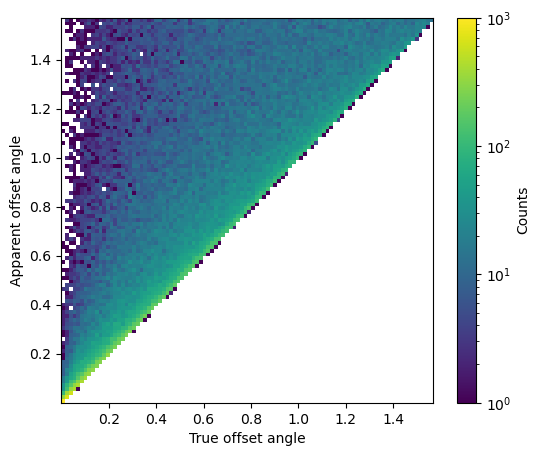

In [3]:
# Simulate N points uniformly distributed within a unit sphere (Monte Carlo),
# then compute each point's "true" 3D offset angle from the disk plane versus
# its "apparent" (projected) offset angle, i.e. what we'd measure in 2D on the sky.
N = 100000
R = 1.0

phi = 2 * np.pi * np.random.random(N)       # random azimuthal angle
costheta = 2 * np.random.random(N) - 1      # uniform in cos(theta) for isotropic sampling on a sphere
u_rand = np.random.random(N)                # NOTE: was named `u`, which clobbered the astropy.units
                                             # alias (`import astropy.units as u`) and broke every
                                             # later `u.Msun`/`u.rad`/`u.deg` call in the notebook.

theta = np.arccos(costheta)
r = R * u_rand**(1/3)                       # uniform volume density within the sphere

# Cartesian coordinates of each simulated point
x = r * np.sin(theta) * np.cos(phi)
y = r * np.sin(theta) * np.sin(phi)
z = r * np.cos(theta)

# True offset angle: angle out of the xy-plane using the full 3D position
true_offset_angle = np.arctan(np.abs(z)/np.sqrt(x**2 + y**2))
# Apparent (projected) offset angle: as it would appear projected onto the x-z plane
apparent_offset_angle = np.arctan(np.abs(z)/np.abs(x))

#plt.scatter(true_offset_angle,apparent_offset_angle,alpha=0.005);

# 2D histogram comparing true vs. apparent offset angle
plt.figure(figsize=(6, 5))
plt.hist2d(true_offset_angle,apparent_offset_angle,bins=100,norm=mpl.colors.LogNorm())
plt.xlabel('True offset angle')
plt.ylabel('Apparent offset angle')
plt.colorbar(label='Counts')
plt.show()

In [4]:
# Convert true/apparent offset angles to degrees and bin by true angle,
# to later look at how much the apparent angle can deviate from the true angle.
true_deg = np.degrees(true_offset_angle)
app_deg  = np.degrees(apparent_offset_angle)

delta_deg = np.abs(app_deg - true_deg)

true_bins = np.linspace(0, 90, 10) 
bin_centers = 0.5 * (true_bins[:-1] + true_bins[1:])

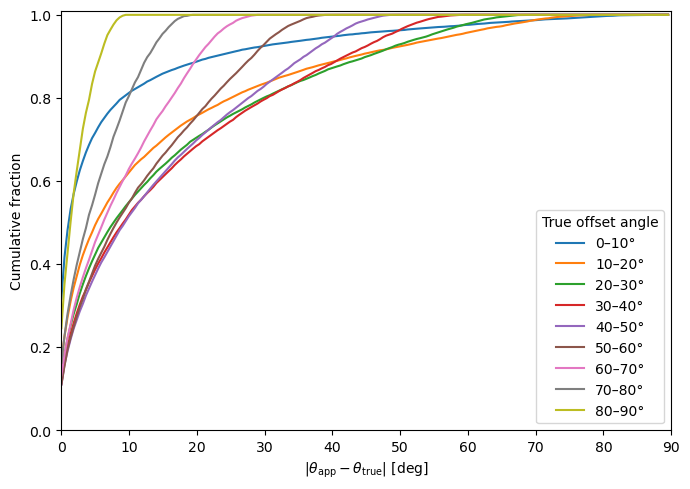

In [5]:
# For each true-angle bin, plot the cumulative distribution of the (absolute)
# difference between apparent and true offset angle -- i.e. how much projection
# effects smear out the true angle for satellites at a given true offset.

delta_max = 90    
delta_bins = np.linspace(0, delta_max, 200)

plt.figure(figsize=(7,5))

for i in range(len(true_bins)-1):
    
    mask = (true_deg >= true_bins[i]) & (true_deg < true_bins[i+1])
    if np.sum(mask) < 1:
        continue  

    hist, edges = np.histogram(delta_deg[mask],bins=delta_bins,density=True)

    cdf = np.cumsum(hist) * np.diff(edges)

    plt.plot(edges[:-1],cdf,label=f'{true_bins[i]:.0f}–{true_bins[i+1]:.0f}°')

#plt.axhline(0.9, color='k', ls='--', lw=1)
#plt.axvline(5, color='k', ls=':', lw=1)

plt.xlabel(r'$|\theta_{\rm app} - \theta_{\rm true}|$ [deg]')
plt.ylabel('Cumulative fraction')
plt.legend(title='True offset angle')
plt.xlim(0, delta_max)
plt.ylim(0, 1.01)
plt.tight_layout()
plt.show()

In [6]:
# Convert to degrees if not already
true_deg = np.degrees(true_offset_angle)
app_deg  = np.degrees(apparent_offset_angle)

# Absolute difference
delta_deg = np.abs(app_deg - true_deg)

# Fraction within 10 degrees
frac_within_10 = np.sum(delta_deg <= 20) / len(delta_deg)

print(f"Fraction of galaxies with apparent angle within 10° of true: {frac_within_10*100:.3f}")

Fraction of galaxies with apparent angle within 10° of true: 77.363


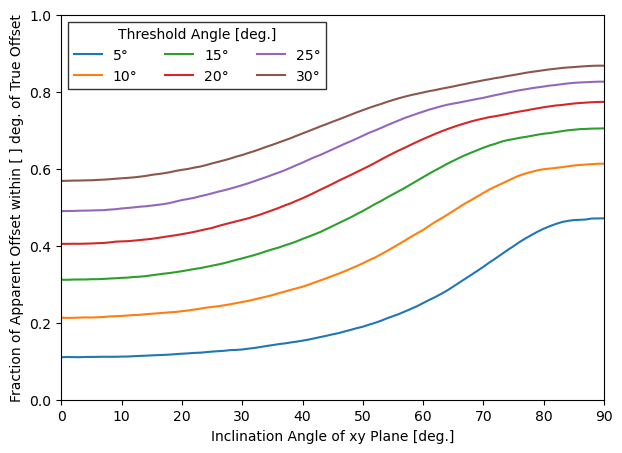

In [7]:
# For a range of inclination angles of the satellite-hosting plane, compute what
# fraction of simulated satellites have an apparent offset angle within a given
# threshold of their true offset angle -- quantifying how projection can bias
# the observed (projected) angle away from the true 3D angle.

inclinations = np.arange(0, 91, 1)
true_deg = np.degrees(true_offset_angle)

plt.figure(figsize=(7,5))

for threshold in [5,10,15,20,25,30]:
    fractions_within_thresh = []
    
    for inc_deg in inclinations:
        inc = np.radians(inc_deg)
        
        # rotate y-z plane by inclination
        x_rot = x
        y_rot = y * np.cos(inc) - z * np.sin(inc)
        z_rot = y * np.sin(inc) + z * np.cos(inc)
        
        # apparent offset angle along projected axes
        app_rot_deg = np.degrees(np.arctan(np.abs(z_rot) / np.abs(x_rot)))
        
        # fraction within threshold degrees
        delta_deg = np.abs(app_rot_deg - true_deg)
        frac = np.sum(delta_deg <= threshold) / len(delta_deg)
        fractions_within_thresh.append(frac)
    
    # plot with label for this threshold
    plt.plot(inclinations, fractions_within_thresh[::-1], label=f'{threshold}°')

plt.xlabel('Inclination Angle of xy Plane [deg.]')
plt.ylabel('Fraction of Apparent Offset within [ ] deg. of True Offset')
plt.xlim(0, 90)
plt.ylim(0, 1)
plt.legend(title='Threshold Angle [deg.]',ncol=3,fancybox=False,edgecolor='k')
plt.show()

## SAGA

Load and process the SAGA survey satellite catalog: combine host + satellite tables, apply sample/quality cuts, and compute each satellite's projected azimuthal (position) angle relative to its host's major axis.

In [8]:
# combine table C1 and C3, attach host properties to each satellite

saga_host_path = '../saga-dr3-tableC1.txt'
saga_sats_path = '../saga-dr3-tableC3.txt'
saga_hosts = Table.read(saga_host_path, format='ascii')
saga_sats = Table.read(saga_sats_path, format = 'ascii')
saga_joined = join(saga_sats, saga_hosts, 'HOSTID', 'left',uniq_col_name='{table_name}{col_name}',table_names=['', 'HOST_'])

print(len(saga_joined))

378


### Filters and Cuts on SAGA Data

In [9]:
# SAGA sample codes (used throughout): 1 = Gold; 2 = Silver; 3 = Participation.
# (Actual sample selection happens later via saga_joined["sample"]==1/2/3 and
# the saga_mask()/_combine_saga_mask() helpers -- this cell previously built
# gold_filter/silver_filter/participation_filter masks that were never used.)

In [10]:
# g-r color of each host (plotted in the next cell). The blue/red split that
# used to be computed here (blue_filter/red_filter at gr=0.7) was never
# referenced anywhere else in the notebook, so it's been dropped.
gr = np.array(saga_hosts['gr'].data)

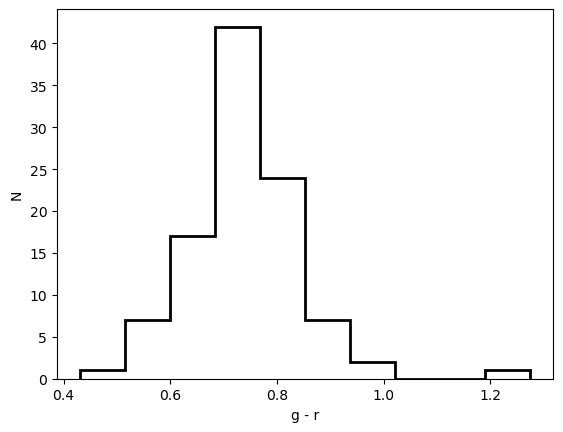

In [11]:
# plot color distribution 

plt.hist(gr,color='k',histtype='step',linewidth=2)
plt.xlabel('g - r')
plt.ylabel('N')
plt.show()

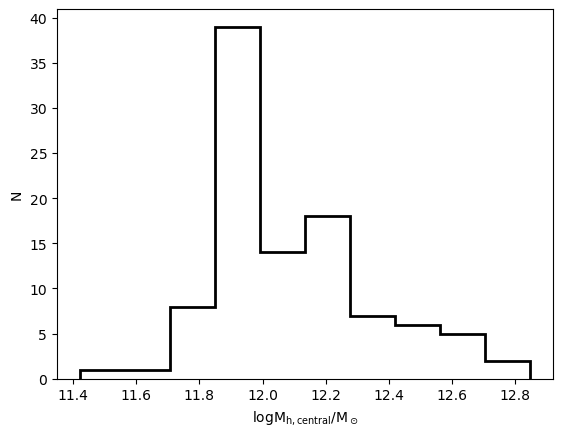

In [12]:
# r200 calculation, from Jingyao

def calc_r200(mhalo, do_print=False):
    # const/cosmo/u/np all come from the Setup cell -- no need to re-import.
    mhalo = mhalo*u.Msun
    delta = 200 ## rho/rho_crit=200

    # calculate r200 with respect to critical density
    rho_c = cosmo.critical_density0
    r200_c = ((3*mhalo/(4.*np.pi*delta*rho_c))**(1./3.)).to(u.kpc)


    # calculate r200 with respect to matter density
    rho_m = cosmo.critical_density0 * cosmo.Om0
    r200_m = ((3*mhalo/(4.*np.pi*delta*rho_m))**(1./3.)).to(u.kpc)
    
    return r200_c.value, r200_m.value

# load Mhalo and calculate R200
hosts_log_mhalo_array = saga_hosts['log(Mhalo)'].data
r200c,r200m = calc_r200((10**hosts_log_mhalo_array))

# plot halo mass distribution

plt.hist(hosts_log_mhalo_array,color='k',histtype='step',linewidth=2)
plt.xlabel(r'$\mathrm{logM_{h,central}/M_\odot}$')
plt.ylabel('N')
plt.show()

### Calculating Azimuthal Angle from Major Axis

In [13]:
# Inspect the joined satellite table
saga_sats

OBJID,HOSTID,PGC,RAdeg,DEdeg,Rhost,rmag,e_rmag,gr,rmag-fiber,sb,ba,PA,Sersic,TELNAME,z,DVhost,log(M*),EW-Halpha,e_EW-Halpha,log(sfr)Halpha,e_log(sfr)Halpha,NUVmag,e_NUVmag,f_NUVmag,log(sfr)NUV,e_log(sfr)NUV,quenched,log(MHI),HIsource,flux-Halpha,e_flux-Halpha,flux-Hbeta,e_flux-Hbeta,flux-NII,e_flux-NII,flux-OIII,e_flux-OIII,flux-SII6717,e_flux-SII6717,flux-SII6731,e_flux-SII6731,flux-note,sample
,,,deg,deg,kpc,mag,mag,mag,mag,mag / arcsec2,,deg,,,,km / s,dex(Msun),1e-10 m,1e-10 m,dex(Msun / yr),dex(Msun / yr),mag,mag,,dex(Msun / yr),dex(Msun / yr),,dex(Msun),,1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),1e-19 W / (nm m2),,
int64,str9,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str5,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,float64,str7,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64
900315730000006229,pgc68312,127631,334.0148085,-64.8787862,216.512,15.586,0.0008,0.465,20.087,21.854,0.678,135.099,1.185,AAT,0.01014,73.321,8.736,12.073,0.3986,-1.544,0.0337,18.508,0.052,1,-1.61,0.0827,0,--,--,1781.456,48.314,570.628,62.299,313.982,33.007,774.563,46.687,461.423,32.208,317.827,27.779,1,1
900316320000001800,pgc1952,-1,8.2736807,-64.6349444,234.685,19.014,0.0065,0.436,22.148,23.336,0.542,0.113,0.839,AAT,0.00859,-49.475,7.187,2.372,0.804,--,--,22.263,0.288,0,-3.257,0.1403,1,--,--,15.442,4.567,2.346,2.018,3.372,3.596,10.537,3.913,1.751,2.549,1.853,3.377,1,2
900322490000007741,pgc1952,1951,8.0041237,-64.3899958,80.501,14.046,0.0002,0.345,19.004,20.943,0.192,113.186,1.366,AAT,0.00916,123.04,9.075,61.071,2.5631,-0.433,0.0361,15.49,0.05,1,-0.548,0.0825,0,--,--,35702.422,580.374,11579.828,408.988,4287.794,404.955,29759.095,965.975,5627.409,401.067,4329.746,367.306,1,1
900328120000004044,pgc68312,68196,332.5294118,-64.5782122,294.065,13.874,0.0002,0.628,19.737,21.468,0.366,48.209,1.065,MIKE,0.00997,22.43,9.6,14.7,0.4,-0.787,0.0331,17.328,0.051,1,-1.138,0.0826,0,--,--,--,--,--,--,--,--,--,--,--,--,--,--,0,1
900328130000003547,pgc68312,322039,333.1089681,-64.5071804,244.484,15.916,0.0006,0.431,18.836,20.65,0.892,140.451,1.665,AAT,0.00937,-157.52,8.567,37.049,1.3828,-1.242,0.035,17.998,0.051,1,-1.405,0.0826,0,--,--,3936.819,48.259,1290.943,36.41,385.725,36.526,2928.618,91.54,554.457,35.047,408.554,35.277,1,1
900328140000005155,pgc68312,-1,333.8210676,-64.5983783,236.665,18.469,0.0065,0.625,23.162,24.535,0.794,-8.997,0.838,COADD,0.00917,-218.003,7.759,-3.515,1.8081,--,--,21.715,4.131,0,-2.892,1.6543,1,--,--,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
900335040000000543,pgc1952,-1,7.9480205,-64.0995786,91.959,19.714,0.0064,0.364,22.25,23.426,0.579,48.339,1.0,AAT,0.00881,16.479,6.828,16.704,1.2187,-3.22,0.042,22.397,0.276,0,-3.31,0.1363,0,--,--,45.294,2.624,13.633,3.303,4.697,1.513,20.835,4.777,5.507,1.656,3.953,0.976,1,2
900335040000004860,pgc1952,-1,8.178446,-64.0559986,124.203,19.195,0.0034,0.556,21.338,22.338,0.736,0.908,0.91,AAT,0.00853,-67.462,7.247,-0.979,0.6117,--,--,23.547,0.655,0,-3.77,0.2739,1,--,--,11.149,3.167,1.907,1.569,1.716,1.877,25.764,4.752,3.222,1.384,2.984,1.173,1,2


In [14]:
# calculate angle

saga_PA = np.zeros(len(saga_sats))
saga_quenched = saga_sats['quenched'].data
for m in range(len(saga_hosts)):
    h_c = SkyCoord(saga_hosts['RAdeg'][m],saga_hosts['DEdeg'][m], frame = "icrs", unit = "deg")
    
    for n in range(len(saga_sats)):

        if saga_hosts['HOSTID'][m] == saga_sats['HOSTID'][n]:

            PA = saga_hosts['PA'][m]
            s_c = SkyCoord(saga_sats['RAdeg'][n],saga_sats['DEdeg'][n], frame = "icrs", unit = "deg")
            relative_angle = h_c.position_angle(s_c).degree
            #print(relative_angle)
            relative_angle_corrected = 90 + relative_angle
            #PA_central = customSimbad.query_object(saga_hosts['HOSTID'][m])['GALDIM_ANGLE'].value
            #print((90 - PA) + relative_angle)
            angle_final = ((90 - PA) + relative_angle_corrected)%360
            saga_PA[n] = angle_final

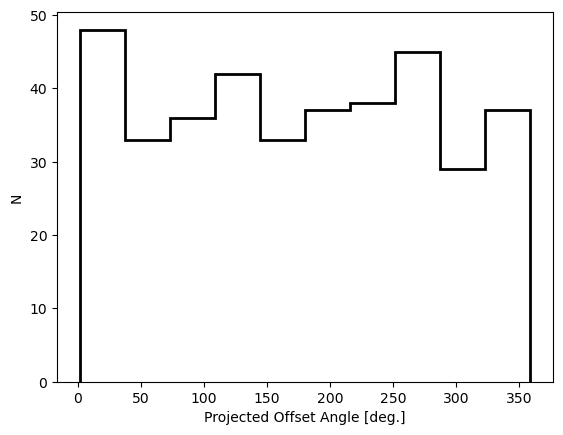

In [15]:
# plot angle distribution

plt.hist(saga_PA,color='k',histtype='step',linewidth=2)
plt.xlabel(r'Projected Offset Angle [deg.]')
plt.ylabel('N')
plt.show()

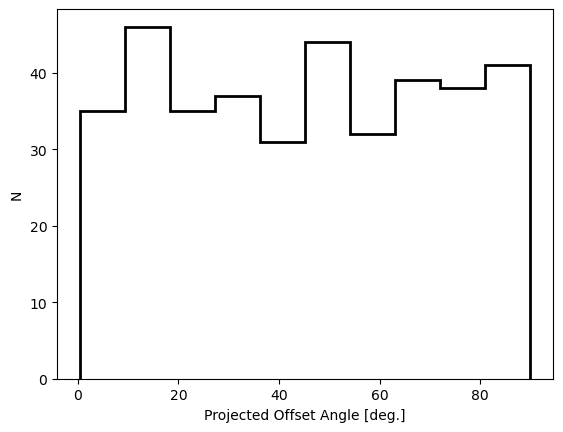

In [16]:
# convert to 0-90

def map_to_0_90(angles):

    angles = np.mod(angles, 360)
    return np.where(angles <= 90, angles,  
           np.where(angles <= 180, 180 - angles,  
           np.where(angles <= 270, angles - 180,  
                    360 - angles))) 

# plot angle distribution

plt.hist(map_to_0_90(saga_PA),color='k',histtype='step',linewidth=2)
plt.xlabel(r'Projected Offset Angle [deg.]')
plt.ylabel('N')
plt.show()

In [17]:
# apply radius limit 

#lmc_limit = saga_sats_gmag < 19

r200c_hosts = np.zeros(len(saga_sats))
r200m_hosts = np.zeros(len(saga_sats))

sats_rhost_array = saga_sats['Rhost'].data

host_data = {saga_hosts['HOSTID'][i]: hosts_log_mhalo_array[i] for i in range(len(saga_hosts))}

# Iterate over the satellites in saga_sats, and match each with its host using HOSTID
for i in range(len(saga_sats)):
    host_id = saga_sats['HOSTID'][i]  # Get the host ID of the current satellite
    # Check if the host exists in saga_hosts
    if host_id in host_data:
        host_mhalo = host_data[host_id]  # Get the host distance 
        mhalo = 10**host_mhalo #since the mhalo is given as the logarithm
        r200c,r200m = calc_r200(mhalo)
        r200c_hosts[i] = r200c
         
radius_limit = sats_rhost_array < r200c_hosts

In [18]:
# make a few different subselections:

sample = np.array(saga_sats['sample'])

index1 = (sats_rhost_array < r200c_hosts) & (sample == 1.)
index2 = (sats_rhost_array < r200c_hosts) & (sample == 2.)
index3 = (sats_rhost_array < r200c_hosts) & (sample == 3.)

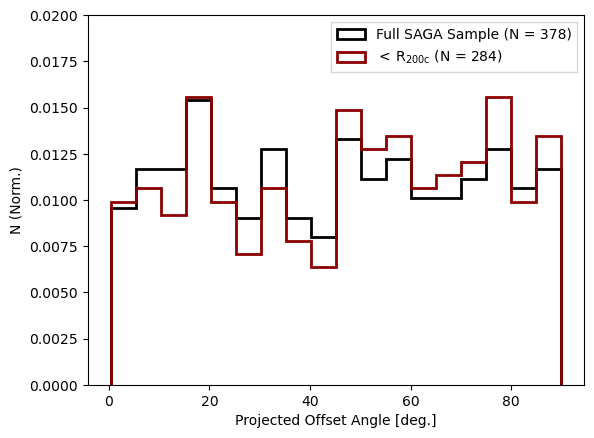

In [19]:
# compare entire SAGA sample with different subselections 

plt.hist(map_to_0_90(saga_PA),color='k',histtype='step',linewidth=2, density = True, bins = 18, label = r'Full SAGA Sample (N = %i)'%len(saga_PA))
plt.hist(map_to_0_90(saga_PA[radius_limit]),color='darkred',histtype='step',linewidth=2, density = True, bins = 18, label = r'$\mathrm{<\,R_{200c}}$ (N = %i)'%len(saga_PA[radius_limit]))

plt.xlabel(r'Projected Offset Angle [deg.]')
plt.ylabel('N (Norm.)')
plt.legend(loc='upper right', fancybox = False)

plt.ylim(0,0.020)

plt.show()

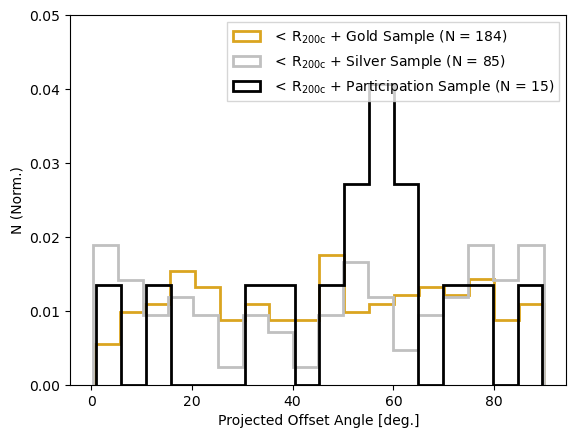

In [20]:
# compare entire SAGA sample with different subselections 

#plt.hist(map_to_0_90(saga_PA),color='k',histtype='step',linewidth=2, density = True, bins = 18, label = r'Full SAGA Sample (N = %i)'%len(saga_PA))
plt.hist(map_to_0_90(saga_PA[index1]),color='goldenrod',histtype='step',linewidth=2, density = True, bins = 18, label = r'$\mathrm{<\,R_{200c}}$ + Gold Sample (N = %i)'%len(saga_PA[index1]))
plt.hist(map_to_0_90(saga_PA[index2]),color='silver',histtype='step',linewidth=2, density = True, bins = 18, label = r'$\mathrm{<\,R_{200c}}$ + Silver Sample (N = %i)'%len(saga_PA[index2]))
plt.hist(map_to_0_90(saga_PA[index3]),color='k',histtype='step',linewidth=2, density = True, bins = 18, label = r'$\mathrm{<\,R_{200c}}$ + Participation Sample (N = %i)'%len(saga_PA[index3]))

plt.xlabel(r'Projected Offset Angle [deg.]')
plt.ylabel('N (Norm.)')
plt.legend(loc='upper right', fancybox = False)

plt.ylim(0,0.050)

plt.show()

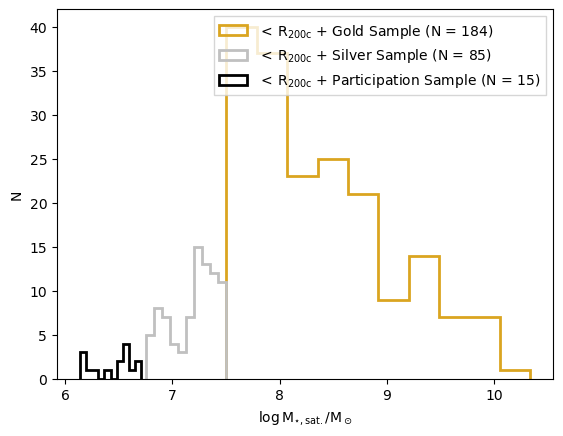

In [21]:
# compare the different SAGA samples (based on satellite stellar mass)

saga_mstar = saga_sats['log(M*)']

plt.hist(saga_mstar[index1],color='goldenrod',histtype='step',linewidth=2, density =False, label = r'$\mathrm{<\,R_{200c}}$ + Gold Sample (N = %i)'%len(saga_mstar[index1]))
plt.hist(saga_mstar[index2],color='silver',histtype='step',linewidth=2, density =False, label = r'$\mathrm{<\,R_{200c}}$ + Silver Sample (N = %i)'%len(saga_mstar[index2]))
plt.hist(saga_mstar[index3],color='k',histtype='step',linewidth=2, density =False, label = r'$\mathrm{<\,R_{200c}}$ + Participation Sample (N = %i)'%len(saga_mstar[index3]))

plt.xlabel(r'$\mathrm{log\, M_{\star,sat.}/M_\odot}$')
plt.ylabel('N')
plt.legend(loc='upper right', fancybox = False)

#plt.ylim(0,0.050)

plt.show()

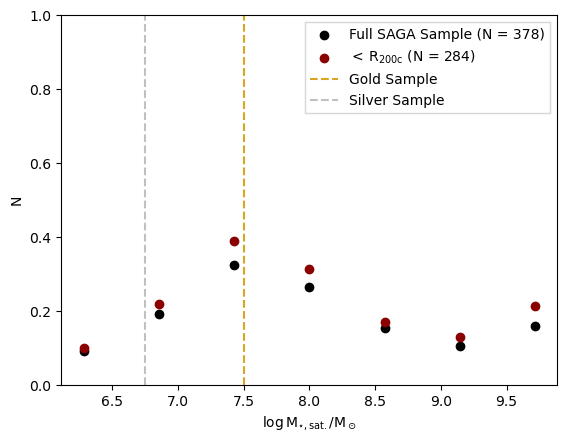

In [22]:
quenched = np.array(saga_sats['quenched'])

q_frac, bin_edges, binnumber = scipy.stats.binned_statistic(saga_mstar,quenched,statistic='mean',bins=7,range=[6,10])
plt.scatter((bin_edges[:-1]+bin_edges[1:])/2,q_frac,color='black', label = r'Full SAGA Sample (N = %i)'%len(saga_PA))

q_frac, bin_edges, binnumber = scipy.stats.binned_statistic(saga_mstar[radius_limit],quenched[radius_limit],statistic='mean',bins=7,range=[6,10])
plt.scatter((bin_edges[:-1]+bin_edges[1:])/2,q_frac,color='darkred', label = r'$\mathrm{<\,R_{200c}}$ (N = %i)'%len(saga_PA[radius_limit]))

plt.axvline(7.5,ls='--',color='goldenrod',label='Gold Sample')
plt.axvline(6.75,ls='--',color='silver',label='Silver Sample')
 
plt.xlabel(r'$\mathrm{log\, M_{\star,sat.}/M_\odot}$')
plt.ylabel('N')
plt.legend(loc='upper right', fancybox = False)
plt.ylim(0,1)
plt.show()

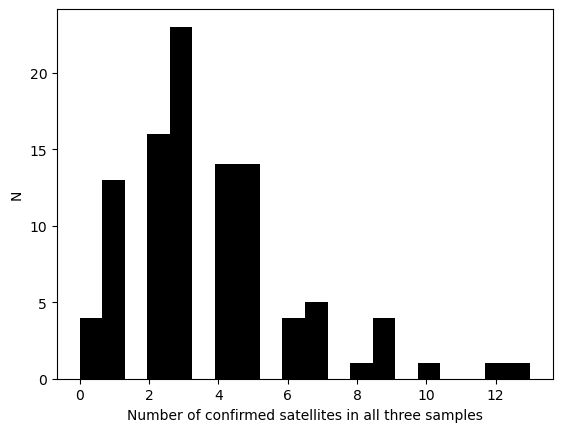

[0 0 0 0]


In [23]:
# there are 4 hosts with no satellites
# nsat-GSPc = Number of confirmed satellites in all three samples: Gold, Silver, Participation

plt.hist(saga_hosts['nsat-GSPc'],bins=20,color='k')
plt.xlabel(r'Number of confirmed satellites in all three samples')
plt.ylabel('N')

plt.show()

print(np.array(saga_hosts['nsat-GSPc'])[np.array(saga_hosts['nsat-GSPc']) == 0])

In [24]:
# there are 16 hosts in the Gold sample with no Gold sample mass (logM > 7.5) satellites 

len(saga_hosts['nsat-Gc'][saga_hosts['nsat-Gc'] == 0])

16

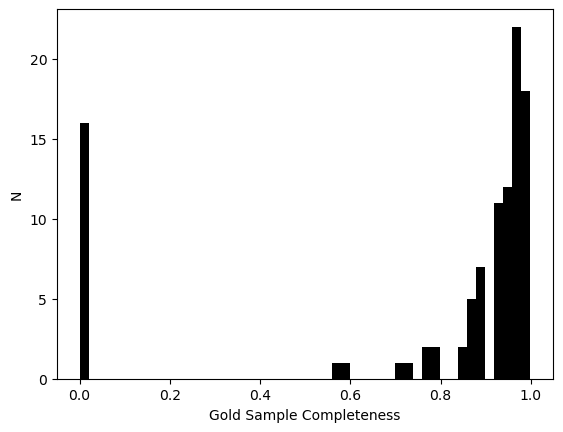

In [25]:
# Gold sample completeness

plt.hist(saga_hosts['nsat-Gc']/saga_hosts['nsat-G'],bins=50,color='k')
plt.xlabel(r'Gold Sample Completeness')
plt.ylabel('N')

plt.show()

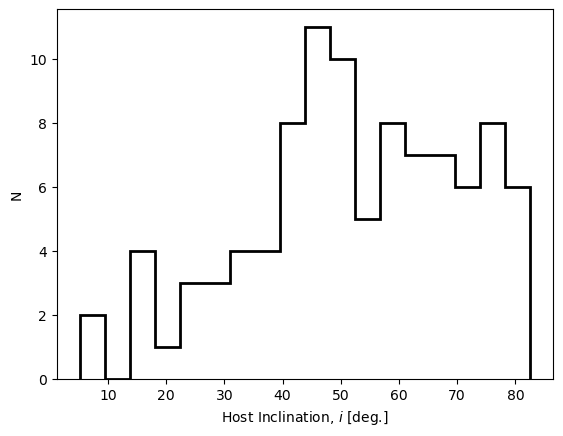

In [26]:
# Host inclination angle from axis ratio (b/a) in the SAGA host table
hostid, idx = np.unique(saga_joined['HOSTID'],return_index=True)
host_ba = saga_joined['HOST_ba'][idx]
host_inclination = (np.arccos(host_ba)*u.rad).to('deg')

plt.hist(host_inclination,color='k',histtype='step', bins = 18, linewidth=2, density =False)

plt.xlabel(r'Host Inclination, $i$ [deg.]')
plt.ylabel('N')
#plt.legend(loc='upper right', fancybox = False)
#plt.ylim(0,1)
plt.show()

In [27]:
# final sample, where we only select satellites within r200c of the host galaxy

#saga_PA = saga_PA[radius_limit]
#saga_quenched = saga_quenched[radius_limit]

index_final = (sats_rhost_array < r200c_hosts) & ((sample == 1.) | (sample == 2.))
saga_PA_raw = saga_PA.copy()
saga_quenched_raw = saga_quenched.copy()

saga_PA = saga_PA[index_final]
saga_90 = map_to_0_90(saga_PA)
saga_quenched = saga_quenched[index_final]

## Importing and Processing ELVES

Load the ELVES host and confirmed-satellite catalogs, query SIMBAD for host position angle / inclination, and compute each satellite's projected offset angle (mirroring the SAGA procedure above).

In [28]:
# import ELVES data 

sats = pd.read_csv('../Carlsten22_ELVES_confirmed_sats - Carlsten22_ELVES_confirmed_sats_compre.csv')
hosts_unfiltered = pd.read_csv(
    "../Carlsten22_ELVES_host - Carlsten22_ELVES_host.csv",
    skipfooter=1,
    engine="python",
)

In [29]:
# Inspect loaded ELVES host table
hosts_unfiltered

,Host,Early_type_host?,Inclination,Position_angle,Host_with_sat_mask,Host_early_type_mask,Host_group_primary_mask,Host_alfa_overlap_mask,Host_r200_coverage_mask,Host_r200_half_coverage_mask,...,R200,Vesc(R200),Netg,Netg_r200,Netg_dim,Netg_dim_r200,Ngas,Ngas_r200,Ngas_dim,Ngas_dim_r200
0,M31,NaN,NaN,NaN,0,0,0,0,0,1,...,379.360431,362.993644,0,0,0,0,0,0,0,0
1,NGC253,NaN,NaN,NaN,1,0,0,0,1,1,...,275.555240,263.666932,2,2,2,2,3,2,2,2
2,NGC628,NaN,NaN,NaN,1,0,0,0,1,1,...,208.146720,199.166624,5,5,5,5,8,4,8,4
3,NGC891,NaN,NaN,NaN,1,0,0,0,0,1,...,299.281096,286.369181,2,2,2,2,1,1,1,1
4,NGC1023,True,NaN,NaN,1,1,0,0,0,1,...,233.492820,223.419215,6,6,6,6,8,8,7,7
5,NGC1291,NaN,NaN,NaN,1,0,0,0,1,1,...,278.670684,266.647966,11,11,11,11,3,3,3,3
6,NGC1808,NaN,NaN,NaN,1,0,0,0,1,1,...,161.977614,154.989397,6,4,6,4,4,4,2,2
7,NGC2683,NaN,NaN,NaN,1,0,0,0,1,1,...,215.729695,206.422447,4,3,4,3,2,2,2,2
8,NGC2903,NaN,NaN,NaN,1,0,0,1,1,1,...,248.620050,237.893809,3,2,3,2,4,4,4,4
9,M81,NaN,NaN,NaN,0,0,1,0,1,1,...,246.295078,235.669144,0,0,0,0,0,0,0,0


In [30]:
# Inspect loaded ELVES satellite table
sats

,Host,Sat_name,RA(deg),DEC(deg),D_SBF(Mpc),D_TRGB(Mpc),Vel(km/s),dvel,Rproj(kpc),Rproj_in_Rvir?,Theta,ETG?,M_g,lgM_star
0,NGC253,NGC247,11.783,-20.757,NaN,3.72,159.0,-100.0,282.2,0,1.092086,0,-18.31,9.41
1,NGC253,dw0047m2623,11.894,-26.390,NaN,3.90,NaN,NaN,68.5,1,NaN,1,-8.86,5.77
2,NGC253,dw0049m2100,12.454,-21.017,NaN,3.44,295.0,36.0,267.9,1,0.981759,0,-12.69,6.62
3,NGC253,dw0050m2444,12.575,-24.737,NaN,3.12,NaN,NaN,51.7,1,NaN,1,-9.53,5.53
4,NGC253,dw0055m2309,13.754,-23.169,NaN,NaN,250.0,-9.0,169.0,1,0.614256,0,-10.26,5.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,NGC6744,dw1905m6316,286.483,-63.272,7.61,NaN,NaN,NaN,113.2,1,NaN,1,-11.44,6.70
247,NGC6744,dw1906m6357,286.742,-63.964,7.31,NaN,NaN,NaN,50.9,1,NaN,1,-13.33,7.46
248,NGC6744,dw1907m6342,286.844,-63.706,7.99,NaN,NaN,NaN,47.6,1,NaN,1,-11.88,6.71
249,NGC6744,dw1908m6343,287.183,-63.730,5.33,NaN,NaN,NaN,26.7,1,NaN,0,-15.21,7.68


In [31]:
customSimbad = Simbad()
customSimbad.reset_votable_fields()
# Add degree-valued RA/DEC + host PA
customSimbad.add_votable_fields('ra', 'dec', 'galdim_angle','galdim_majaxis','galdim_minaxis')

In [32]:
# Spot-check host name column
hosts_unfiltered['Host']

0         M31
1      NGC253
2      NGC628
3      NGC891
4     NGC1023
5     NGC1291
6     NGC1808
7     NGC2683
8     NGC2903
9         M81
10    NGC3115
11    NGC3344
12    NGC3379
13    NGC3521
14    NGC3556
15    NGC3621
16    NGC3627
17    NGC4258
18    NGC4517
19    NGC4565
20       M104
21    NGC4631
22    NGC4736
23    NGC4826
24    NGC5055
25      CEN A
26    NGC5194
27    NGC5236
28    NGC5457
29    NGC6744
Name: Host, dtype: object

In [33]:
# get position angle from ELVES hosts 
# NOTE: this is a first-pass computation of host inclination/PA via SIMBAD;
# it gets refined below (see 'Recompute Inclination Angle with new filter').

hosts_missing_pa = []
pa_val = []
elves_inclination = []
elves_PA = []
pa_indices = []


for i, host in enumerate(hosts_unfiltered['Host']):
    tab = customSimbad.query_object(host)

    val = tab['galdim_angle']
    major_axis = tab['galdim_majaxis'].value
    minor_axis = tab['galdim_minaxis'].value
    
    #print(val[0])
    pa_val.append(val.value)
    if np.ma.is_masked(val):
        hosts_missing_pa.append(host)
    else:
        pa_indices.append(i)
        print(hosts_unfiltered['Host'][i])
        print("major_axis:", major_axis)
        print("minor_axis:", minor_axis)
        #print(' d')
        inclination_angle = np.arccos((minor_axis)/(major_axis))*180/np.pi
        print("inclination_angle:", inclination_angle)
        elves_inclination.append(inclination_angle)
        elves_PA.append(val)

hosts  = hosts_unfiltered.iloc[pa_indices].copy()
#print("Hosts missing GALDIM_ANGLE:")
#for h in hosts_missing_pa:
    #print(h)
    #print(customSimbad.query_object(h)['galdim_angle'])

M31
major_axis: [199.52999877929688]
minor_axis: [70.79000091552734]
inclination_angle: [69.21981048583984]
NGC253
major_axis: [28.84000015258789]
minor_axis: [5.889999866485596]
inclination_angle: [78.2155532836914]


NGC628
major_axis: [6.703949928283691]
minor_axis: [6.6529998779296875]
inclination_angle: [7.068383693695068]


NGC891
major_axis: [12.300000190734863]
minor_axis: [2.450000047683716]
inclination_angle: [78.51057434082031]


NGC1291
major_axis: [10.470000267028809]
minor_axis: [8.130000114440918]
inclination_angle: [39.05838394165039]
NGC1808
major_axis: [9.99761962890625]
minor_axis: [3.788100004196167]
inclination_angle: [67.73442077636719]


NGC2683
major_axis: [8.710000038146973]
minor_axis: [2.569999933242798]
inclination_angle: [72.83867645263672]
NGC2903
major_axis: [8.858909606933594]
minor_axis: [4.617269992828369]
inclination_angle: [58.5871696472168]


...

M104
major_axis: [8.510000228881836]
minor_axis: [5.010000228881836]
inclination_angle: [53.93383026123047]
NGC4631
major_axis: [16.56209945678711]
minor_axis: [3.13850998878479]
inclination_angle: [79.076416015625]


NGC4736
major_axis: [6.990779876708984]
minor_axis: [5.861070156097412]
inclination_angle: [33.0284423828125]
NGC4826
major_axis: [10.993399620056152]
minor_axis: [6.22445011138916]
inclination_angle: [55.51441955566406]


NGC5055
major_axis: [13.180000305175781]
minor_axis: [7.940000057220459]
inclination_angle: [52.956016540527344]
CEN A
major_axis: [25.700000762939453]
minor_axis: [17.780000686645508]
inclination_angle: [46.224952697753906]


NGC5194
major_axis: [9.043789863586426]
minor_axis: [7.783989906311035]
inclination_angle: [30.60472869873047]


NGC6744
major_axis: [17.3799991607666]
minor_axis: [10.960000038146973]
inclination_angle: [50.90486145019531]


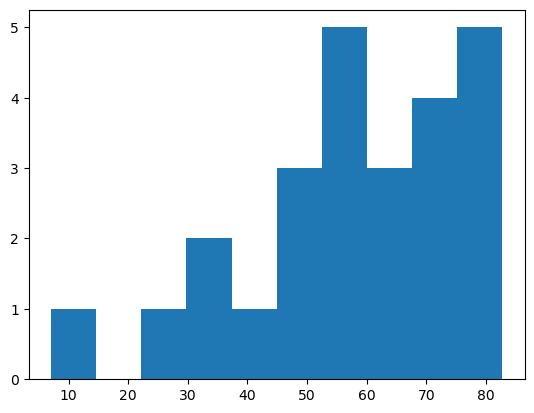

In [34]:
# Quick look at the distribution of host inclinations from the first-pass query above
plt.hist(np.array(elves_inclination), linewidth=2, density =False)
plt.show()

In [35]:
# Manual inclination notes/spot-checks for a few hosts gathered from NED
# (kept as a reference / sanity-check, not used programmatically below).
"""NGC1023, 90  # https://ned.ipac.caltech.edu/byname?objname=NGC1023&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1
NGC3379, spherical: 90 or 0  # https://ned.ipac.caltech.edu/byname?objname=NGC3379&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1
NGC4258, 150 # https://ned.ipac.caltech.edu/byname?objname=NGC4258&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1
NGC5236, face-on: 0 # https://ned.ipac.caltech.edu/byname?objname=NGC5236&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1
NGC5457, also face-on # https://ned.ipac.caltech.edu/byname?objname=NGC5457&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1"""

'NGC1023, 90  # https://ned.ipac.caltech.edu/byname?objname=NGC1023&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1\nNGC3379, spherical: 90 or 0  # https://ned.ipac.caltech.edu/byname?objname=NGC3379&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1\nNGC4258, 150 # https://ned.ipac.caltech.edu/byname?objname=NGC4258&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1\nNGC5236, face-on: 0 # https://ned.ipac.caltech.edu/byname?objname=NGC5236&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1\nNGC5457, also face-on # https://ned.ipac.caltech.edu/byname?objname=NGC5457&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1'

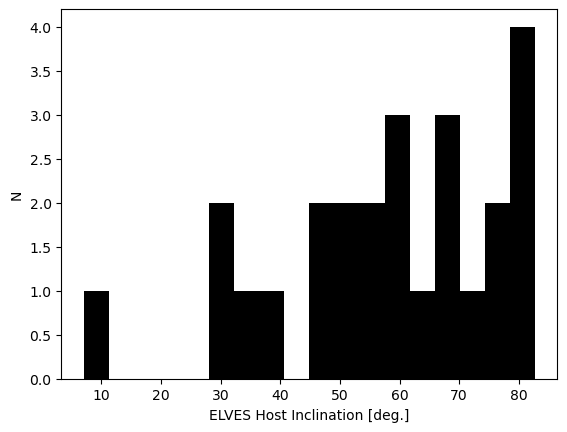

In [36]:
# plot ELVES host inclination

elves_inclination_reformat = np.concatenate([c.filled(np.nan) for c in elves_inclination])
elves_PA_reformat = np.concatenate([c.astype(float).filled(np.nan) for c in elves_PA])

plt.hist(elves_inclination_reformat,color='k',bins=18)
plt.xlabel("ELVES Host Inclination [deg.]")
plt.ylabel("N")
plt.show()

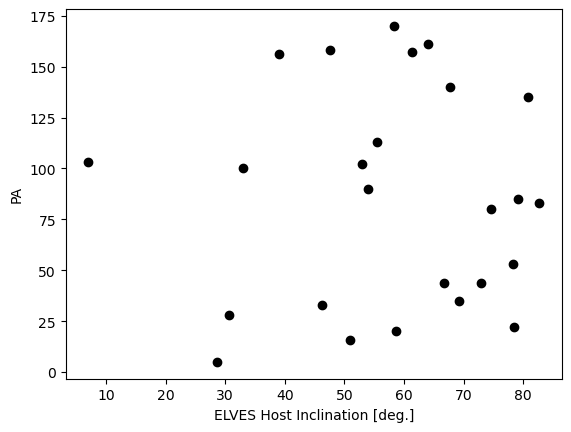

In [37]:
# Sanity check: host inclination vs. position angle (first-pass values)
plt.scatter(elves_inclination_reformat,elves_PA_reformat,color='k')
plt.xlabel("ELVES Host Inclination [deg.]")
plt.ylabel("PA")
plt.show()

In [38]:
# Refine the host list to only those with a valid (unmasked) position angle from SIMBAD
valid_indices = []

for i, host in enumerate(hosts_unfiltered['Host']):
    tab = customSimbad.query_object(host)
    val = tab['galdim_angle']

    if not np.ma.is_masked(val):  # keep only if PA exists
        valid_indices.append(i)

# Keep only rows with valid PA
hosts = hosts_unfiltered.iloc[valid_indices].copy()

In [39]:
# Recompute the final ELVES satellite position angles -- this elves_PA is the one
# actually used throughout the rest of the notebook, analogous to the SAGA PA calc.
# (np / SkyCoord already imported in Setup; dproj/mass tracking removed below --
# elves_dproj/elves_mass were computed here but never referenced anywhere else.)

pa_list = []
kept_indices = []  # lets you map back to rows in `sats`

for r in range(len(sats)):
    host = sats['Host'].get(r)

    # Query host once each place we need
    h_table = Simbad.query_object(host)
    pa_tab  = customSimbad.query_object(host)

    # Skip if PA is missing/masked
    pa_col = pa_tab['galdim_angle']
    if np.ma.is_masked(pa_col):
        continue

    # Build coords (skip if satellite coords missing)
    try:
        h_coords = SkyCoord(ra=h_table['ra'], dec=h_table['dec'], frame='icrs')
        s_coords = SkyCoord(ra=sats['RA(deg)'].get(r),
                            dec=sats['DEC(deg)'].get(r),
                            frame='icrs', unit='deg')
    except Exception:
        # If any coord is malformed, skip this row
        continue

    position_angle = h_coords.position_angle(s_coords).degree

    # Compute the angle using GALDIM_ANGLE value
    angle = ((90 - pa_col.value) + position_angle + 90) % 360

    # Append valid values
    pa_list.append(angle)
    kept_indices.append(r)

# Final array contains ONLY rows with valid PA
elves_PA = np.array(pa_list, dtype=float)

#### Recompute Inclination Angle with new filter

In [40]:
# Recompute host inclination using the refined host list (`hosts`) from above.
hosts_missing_pa, pa_val, elves_inclination, elves_PA_host, pa_indices = [], [], [], [], []

for i in range(len(hosts)):
    host = hosts["Host"].iloc[i]
    tab = customSimbad.query_object(host)

    val = tab["galdim_angle"]
    major_axis = tab["galdim_majaxis"].value
    minor_axis = tab["galdim_minaxis"].value

    pa_val.append(val.value)
    if np.ma.is_masked(val):
        hosts_missing_pa.append(host)
    else:
        pa_indices.append(i)
        print(host)
        inclination_angle = np.degrees(np.arccos(minor_axis / major_axis))
        elves_inclination.append(inclination_angle)
        elves_PA_host.append(val)

M31
NGC253
NGC628
NGC891
NGC1291
NGC1808
NGC2683
NGC2903
M81
NGC3115
NGC3344
NGC3521
NGC3556
NGC3621
NGC3627
NGC4517
NGC4565
M104
NGC4631
NGC4736
NGC4826
NGC5055
CEN A
NGC5194
NGC6744


In [41]:
# Number of hosts with a usable inclination measurement
print(len(elves_inclination))

25


In [42]:
#elves quench values
elves_quenched = sats['ETG?'].iloc[kept_indices]

In [43]:
# Sanity check on the SAGA joined-table length
print(len(saga_joined))

378


In [44]:
# Summary counts for the final ELVES sample
print('number of ELVES hosts =',len(hosts))
print('number of ELVES satellites =',len(elves_PA))

number of ELVES hosts = 25
number of ELVES satellites = 177


# Working with Both ELVES and SAGA

Combine the processed SAGA and ELVES samples to compare their satellite angular distributions and quenched fractions.

### Quench Fraction Calculation

In [45]:
# ELVES angles, folded to 0-90 deg. elves_90 holds SIMBAD's masked-column
# format (each entry is a 1-element array), so elves_90_correct unwraps it
# into a plain float array -- this is the array actually used from here on.
elves_90 = map_to_0_90(elves_PA)
elves_90_correct = []
for i in range(len(elves_90)):
    elves_90_correct.append(elves_90[i][0])

In [46]:
# Overall ELVES quenched fraction (used later as the fit amplitude 'a' for ELVES)
elves_mean = np.mean(elves_quenched)

In [47]:
# Global plot styling -- serif fonts to match publication figures
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']  # Or 'Times'
plt.rcParams['mathtext.fontset'] = 'stix'  # For math symbols to match Times
plt.rcParams['mathtext.rm'] = 'Times New Roman'

## Normalized Count per Azimuthal Angle Bin

Compare the (normalized) distribution of projected offset angles between SAGA and ELVES. The left panel is reserved for an optional TNG100 comparison (see `INCLUDE_TNG`).

/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_81542/1523964846.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_hist.legend(fontsize=14,loc='upper right', fancybox=False, edgecolor='black',ncol=1,title='TNG100:',title_fontsize=14)


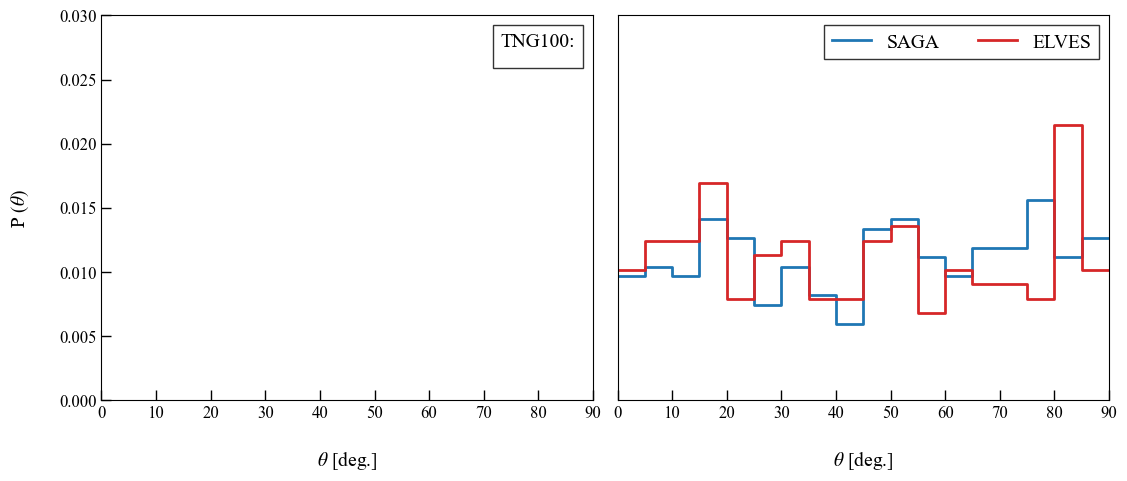

In [48]:
# New high-contrast colors
saga_line = '#1f77b4'
saga_fill = '#aec7e8'
elves_line = '#d62728'
elves_fill = '#ff9896'

fig, (ax_hist,ax_hist2) = plt.subplots(1, 2, figsize=(13, 5))

# ===============================
# TOP PANEL — STEP HISTOGRAM
# ===============================

# NOTE: the left panel (ax_hist) is reserved for an optional TNG100 comparison;
# it is intentionally left without plotted data here since TNG100 histogram
# lines are not computed in this notebook (see the INCLUDE_TNG note in Setup).


# saga_90/elves_90 already computed above (SAGA/ELVES import sections) --
# not recomputed here.
bins = np.linspace(0, 90, 19)

counts_saga, _ = np.histogram(saga_90, bins=bins, density=True)
ax_hist2.step(bins, np.append(counts_saga, counts_saga[-1]),where='post', color=saga_line, linewidth=2, label='SAGA')

counts_elves, _ = np.histogram(elves_90, bins=bins, density=True)
ax_hist2.step(bins, np.append(counts_elves, counts_elves[-1]),where='post', color=elves_line, linewidth=2, label='ELVES')
#ax_hist.scatter(bins, np.append(counts_elves, counts_elves[-1]), color=elves_line, label='ELVES')

#angle_grid_deg = np.linspace(0, 90, 300)
#uniform_density = 1/90
#ax_hist.axhspan(uniform_density, uniform_density, color='black')

max_density = max(counts_saga.max(), counts_elves.max())

ax_hist.set_ylabel(r'P ($\theta$)', fontsize=14, labelpad=20)
ax_hist.set_xlabel(r'$\theta$ [deg.]', fontsize=14, labelpad=20)
ax_hist2.set_xlabel(r'$\theta$ [deg.]', fontsize=14, labelpad=20)

ax_hist.set_xlim(0, 90)
ax_hist2.set_xlim(0, 90)

ax_hist.set_ylim(0, 0.030)
ax_hist2.set_ylim(0, 0.030)

ax_hist.legend(fontsize=14,loc='upper right', fancybox=False, edgecolor='black',ncol=1,title='TNG100:',title_fontsize=14)
ax_hist2.legend(fontsize=14,loc='upper right', fancybox=False, edgecolor='black',ncol=2)

ax_hist.tick_params(axis="both", which="major", direction="in", labelsize=12, length=7, width=1)
ax_hist.tick_params(axis="both", which="minor", direction="in", labelsize=12, length=2, width=1)

ax_hist2.tick_params(axis="both", which="major", direction="in", labelsize=12, length=7, width=1)
ax_hist2.tick_params(axis="both", which="minor", direction="in", labelsize=12, length=2, width=1)

ax_hist2.set_yticks([])

plt.subplots_adjust(wspace=0.05)
plt.show()

In [49]:
# Shared angle bin-centers (0-90 deg) used by the SAGA, ELVES, and (optional) TNG100 fits below
angle_array = np.loadtxt('../angle_array.txt')

### Mean Angle 

In [50]:
# import TNG100 data (three satellite stellar-mass thresholds: 1e6, 1e7, 1e8 Msun)
if INCLUDE_TNG:
    # import TNG100 data

    df_tng100_1e8 = pd.read_csv("satellite_1e8/centrals_satellites_tng100_mstar_1e8.csv")
    df_tng100_host_mh_1e8 = pd.read_csv("satellite_1e8/centrals_satellites_tng100_host_mh_1e8.csv")
    df_tng100_alpha_1e8 = pd.read_csv("satellite_1e8/centrals_satellites_tng100_alpha_1e8.csv")

    index_1e8 = (df_tng100_host_mh_1e8['host_mh'] > 12) & (df_tng100_host_mh_1e8['host_mh'] < 12.5)

    df_tng100_1e7 = pd.read_csv("satellite_1e7/centrals_satellites_tng100_mstar_1e7.csv")
    df_tng100_host_mh_1e7 = pd.read_csv("satellite_1e7/centrals_satellites_tng100_host_mh_1e7.csv")
    df_tng100_alpha_1e7 = pd.read_csv("satellite_1e7/centrals_satellites_tng100_alpha_1e7.csv")

    index_1e7 = (df_tng100_host_mh_1e7['host_mh'] > 12) & (df_tng100_host_mh_1e7['host_mh'] < 12.5)

    df_tng100_1e6 = pd.read_csv("satellite_1e6/centrals_satellites_tng100_mstar_1e6.csv")
    df_tng100_host_mh_1e6 = pd.read_csv("satellite_1e6/centrals_satellites_tng100_host_mh_1e6.csv")
    df_tng100_alpha_1e6 = pd.read_csv("satellite_1e6/centrals_satellites_tng100_alpha_1e6.csv")

    index_1e6 = (df_tng100_host_mh_1e6['host_mh'] > 12) & (df_tng100_host_mh_1e6['host_mh'] < 12.5)
else:
    print('INCLUDE_TNG is False -- skipping TNG100 data import.')

INCLUDE_TNG is False -- skipping TNG100 data import.


In [51]:
if INCLUDE_TNG:
    print(np.mean(df_tng100_alpha_1e8[index_1e8]),np.std(df_tng100_alpha_1e8[index_1e8]))
    print(np.mean(df_tng100_alpha_1e7[index_1e7]),np.std(df_tng100_alpha_1e7[index_1e7]))
    print(np.mean(df_tng100_alpha_1e6[index_1e6]),np.std(df_tng100_alpha_1e6[index_1e6]))
else:
    print('INCLUDE_TNG is False -- skipping TNG100 alpha summary stats.')

INCLUDE_TNG is False -- skipping TNG100 alpha summary stats.


### One-Sample KS-Test

INCLUDE_TNG is False -- skipping TNG100 CDF curves.


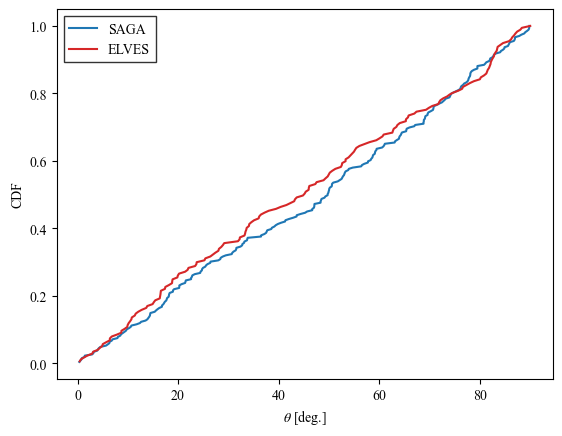

In [52]:
sort_saga = np.argsort(saga_90)
sort_elves = np.argsort(np.array(elves_90_correct))

cdf_saga = np.arange(1, len(saga_90)+1) / len(saga_90)
cdf_elves = np.arange(1, len(elves_90_correct)+1) / len(elves_90_correct)

plt.plot(saga_90[sort_saga], cdf_saga, color=saga_line, label='SAGA')
plt.plot(np.array(elves_90_correct)[sort_elves], cdf_elves, color=elves_line, label='ELVES')

if INCLUDE_TNG:

    angles_1d_1e8 = df_tng100_alpha_1e8.iloc[:,0].to_numpy()
    sort_tng100_1e8 = np.argsort(angles_1d_1e8)
    cdf_tng100_1e8 = np.arange(1, len(angles_1d_1e8)+1) / len(angles_1d_1e8)
    plt.plot(angles_1d_1e8[sort_tng100_1e8], cdf_tng100_1e8, color='black', ls = '-', label='TNG 1e8')

    angles_1d_1e7 = df_tng100_alpha_1e7.iloc[:,0].to_numpy()
    sort_tng100_1e7 = np.argsort(angles_1d_1e7)
    cdf_tng100_1e7 = np.arange(1, len(angles_1d_1e7)+1) / len(angles_1d_1e7)
    plt.plot(angles_1d_1e7[sort_tng100_1e7], cdf_tng100_1e7, color='black', ls = '--', label='TNG 1e7')

    angles_1d_1e6 = df_tng100_alpha_1e6.iloc[:,0].to_numpy()
    sort_tng100_1e6 = np.argsort(angles_1d_1e6)
    cdf_tng100_1e6 = np.arange(1, len(angles_1d_1e6)+1) / len(angles_1d_1e6)
    plt.plot(angles_1d_1e6[sort_tng100_1e6], cdf_tng100_1e6, color='black', ls = ':', label='TNG 1e6')
else:
    print('INCLUDE_TNG is False -- skipping TNG100 CDF curves.')

# Plot

plt.xlabel(r'$\theta$ [deg.]')
plt.ylabel('CDF')
plt.legend(fancybox=False,edgecolor='k',ncol=1)
plt.show()

In [53]:
# implement one-sample K-S test
# see https://www.astroml.org/astroML-notebooks/chapter4/astroml_chapter4_Comparison_of_distributions.html

import scipy.stats as stats

# example from website
#np.random.seed(0)
#vals = np.random.normal(loc=0, scale=1, size= 1000)
#print(f'Normal: {stats.kstest(vals, "norm")}')
#print(f'Uniform: {stats.kstest(vals, "uniform")}')

print(f'Uniform: {stats.kstest(saga_90[sort_saga], "uniform",args=(0, 90))}')
print(f'Uniform: {stats.kstest(np.array(elves_90_correct)[sort_elves], "uniform",args=(0, 90))}')


if INCLUDE_TNG:


    print(f'Uniform: {stats.kstest(angles_1d_1e8[sort_tng100_1e8], "uniform",args=(0, 90))}')
    print(f'Uniform: {stats.kstest(angles_1d_1e7[sort_tng100_1e7], "uniform",args=(0, 90))}')
    print(f'Uniform: {stats.kstest(angles_1d_1e6[sort_tng100_1e6], "uniform",args=(0, 90))}')
else:
    print('INCLUDE_TNG is False -- skipping TNG100 uniformity KS-tests.')

Uniform: KstestResult(statistic=0.06845115462282736, pvalue=0.15345478766419884, statistic_location=46.64387529151915, statistic_sign=-1)
Uniform: KstestResult(statistic=0.052627365231793566, pvalue=0.6907804344863296, statistic_location=79.99070015899702, statistic_sign=-1)
INCLUDE_TNG is False -- skipping TNG100 uniformity KS-tests.


### Two-Sample KS-Test (+ One-Sample KS-Test for Q and SF subsample)

In [54]:
# Flatten the ELVES 0-90 angle list (each entry was a 1-element array) into a plain array
#elves_quenched = elves_quenched.to_numpy()
elves_90_correct = np.array(elves_90_correct)

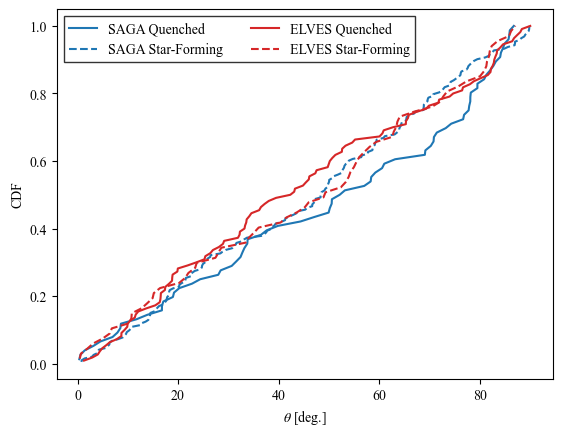

In [55]:
# Split SAGA/ELVES samples into quenched (Q) vs. star-forming (SF) subsets
saga_q = (saga_quenched == 1)
saga_sf = (saga_quenched == 0)
sort_saga_q = np.argsort(saga_90[saga_q])
sort_saga_sf = np.argsort(saga_90[saga_sf])

#sort_elves = np.argsort(np.array(elves_90_correct))

elves_q = (elves_quenched == 1)
elves_sf = (elves_quenched == 0)
sort_elves_q = np.argsort(elves_90_correct[elves_q])
sort_elves_sf = np.argsort(elves_90_correct[elves_sf])

cdf_saga_q = np.arange(1, len(saga_90[saga_q])+1) / len(saga_90[saga_q])
cdf_saga_sf = np.arange(1, len(saga_90[saga_sf])+1) / len(saga_90[saga_sf])

cdf_elves_q = np.arange(1, len(elves_90_correct[elves_q])+1) / len(elves_90_correct[elves_q])
cdf_elves_sf = np.arange(1, len(elves_90_correct[elves_sf])+1) / len(elves_90_correct[elves_sf])

plt.plot(saga_90[saga_q][sort_saga_q], cdf_saga_q, color=saga_line, ls = '-', label='SAGA Quenched')
plt.plot(saga_90[saga_sf][sort_saga_sf], cdf_saga_sf, color=saga_line, ls = '--', label='SAGA Star-Forming')

plt.plot(elves_90_correct[elves_q][sort_elves_q], cdf_elves_q, color=elves_line, ls = '-', label='ELVES Quenched')
plt.plot(elves_90_correct[elves_sf][sort_elves_sf], cdf_elves_sf, color=elves_line, ls = '--', label='ELVES Star-Forming')

# plot isotropic expectation
#theta_ref = np.linspace(0, 90, 200)
#cdf_iso = theta_ref / 90.0
#plt.plot(theta_ref, cdf_iso, color='black', ls='-', lw=2)

plt.xlabel(r'$\theta$ [deg.]')
plt.ylabel('CDF')
plt.legend(fancybox=False,edgecolor='k',ncol=2)
plt.show()

In [56]:
# One-sample KS test: is each Q/SF subsample consistent with a uniform angle distribution?
# two-sample KS test for SAGA/ELVES

print('SAGA:')
print(f'Q against Uniform Dist.: {stats.kstest(saga_90[saga_q][sort_saga_q], "uniform",args=(0, 90))}')
print(f'SF against Uniform Dist.: {stats.kstest(saga_90[saga_sf][sort_saga_sf], "uniform",args=(0, 90))}')
print(' ')
print('ELVES:')
print(f'Q against Uniform Dist.: {stats.kstest(elves_90_correct[elves_q][sort_elves_q], "uniform",args=(0, 90))}')
print(f'SF against Uniform Dist.: {stats.kstest(elves_90_correct[elves_sf][sort_elves_sf], "uniform",args=(0, 90))}')

#print(f'ELVES Q vs. SF: {stats.ks_2samp(elves_90_correct[elves_q][sort_elves_q], elves_90_correct[elves_sf][sort_elves_sf])}')

SAGA:
Q against Uniform Dist.: KstestResult(statistic=0.16188773749369179, pvalue=0.033015492839219854, statistic_location=69.04358058495858, statistic_sign=-1)
SF against Uniform Dist.: KstestResult(statistic=0.05712538464382244, pvalue=0.535557665156098, statistic_location=46.64387529151915, statistic_sign=-1)
 
ELVES:
Q against Uniform Dist.: KstestResult(statistic=0.061494764014825065, pvalue=0.7763165106411352, statistic_location=34.556380329574836, statistic_sign=1)
SF against Uniform Dist.: KstestResult(statistic=0.0742161155066775, pvalue=0.8275286414006502, statistic_location=52.35109218664576, statistic_sign=-1)


In [57]:
# Two-sample KS test: are the Q and SF angle distributions different from each other?
# two-sample KS test for SAGA/ELVES

print(f'SAGA Q vs. SF: {stats.ks_2samp(saga_90[saga_q][sort_saga_q], saga_90[saga_sf][sort_saga_sf])}')
print(' ')
print(f'ELVES Q vs. SF: {stats.ks_2samp(elves_90_correct[elves_q][sort_elves_q], elves_90_correct[elves_sf][sort_elves_sf])}')

SAGA Q vs. SF: KstestResult(statistic=0.16157622034360514, pvalue=0.10178829571223422, statistic_location=68.83935850018537, statistic_sign=-1)
 
ELVES Q vs. SF: KstestResult(statistic=0.12306648575305291, pvalue=0.5040314649247061, statistic_location=53.27694524733624, statistic_sign=1)


In [58]:
if INCLUDE_TNG:
    # TNG100-1 plot

    # 1e8

    df_tng100_1e8 = pd.read_csv("satellite_1e8/centrals_satellites_tng100_mstar_1e8.csv")
    df_tng100_host_mh_1e8 = pd.read_csv("satellite_1e8/centrals_satellites_tng100_host_mh_1e8.csv")
    df_tng100_alpha_1e8 = pd.read_csv("satellite_1e8/centrals_satellites_tng100_alpha_1e8.csv")
    tng100_sfr_info_1e8 = pd.read_csv("satellite_1e8/tng100_sfr_info_1e8.csv")

    index = (df_tng100_host_mh_1e8['host_mh'] > 12) & (df_tng100_host_mh_1e8['host_mh'] < 12.5)
    sfr_interp = np.log10((10**(0.75*tng100_sfr_info_1e8['mstar'][index]-7.5))/10)
    index_sf = (10**sfr_interp <= tng100_sfr_info_1e8['sfr'][index])
    index_q = (10**sfr_interp > tng100_sfr_info_1e8['sfr'][index])
    q_sf_array = np.ones(len(tng100_sfr_info_1e8['host_mh'][index]))
    q_sf_array[index_sf] = 0.

    angles_all = df_tng100_alpha_1e8.iloc[:, 0]
    angles_q  = angles_all[index][index_q]
    angles_sf = angles_all[index][index_sf]
    angles_q_sorted  = np.sort(angles_q)
    angles_sf_sorted = np.sort(angles_sf)
    cdf_q  = np.arange(1, len(angles_q_sorted)  + 1) / len(angles_q_sorted)
    cdf_sf = np.arange(1, len(angles_sf_sorted) + 1) / len(angles_sf_sorted)
    plt.plot(angles_q_sorted,  cdf_q,  color='black', ls='-',  label='TNG 1e8 Q')
    plt.plot(angles_sf_sorted, cdf_sf, color='black', ls='--', label='TNG 1e8 SF')

    # two-sample KS test
    print(f'TNG100-1, Msat > 1e8: {stats.ks_2samp(angles_q_sorted, angles_sf_sorted)}')
    # one-sample KS test
    print(f'Q against Uniform Dist.: {stats.kstest(angles_q_sorted, "uniform",args=(0, 90))}')
    print(f'SF against Uniform Dist.: {stats.kstest(angles_sf_sorted, "uniform",args=(0, 90))}')
    print(' ')

    # 1e7

    df_tng100_1e7 = pd.read_csv("satellite_1e7/centrals_satellites_tng100_mstar_1e7.csv")
    df_tng100_host_mh_1e7 = pd.read_csv("satellite_1e7/centrals_satellites_tng100_host_mh_1e7.csv")
    df_tng100_alpha_1e7 = pd.read_csv("satellite_1e7/centrals_satellites_tng100_alpha_1e7.csv")
    tng100_sfr_info_1e7 = pd.read_csv("satellite_1e7/tng100_sfr_info_1e7.csv")

    index = (df_tng100_host_mh_1e7['host_mh'] > 12) & (df_tng100_host_mh_1e7['host_mh'] < 12.5)
    sfr_interp = np.log10((10**(0.75*tng100_sfr_info_1e7['mstar'][index]-7.5))/10)
    index_sf = (10**sfr_interp <= tng100_sfr_info_1e7['sfr'][index])
    index_q = (10**sfr_interp > tng100_sfr_info_1e7['sfr'][index])
    q_sf_array = np.ones(len(tng100_sfr_info_1e7['host_mh'][index]))
    q_sf_array[index_sf] = 0.

    angles_all = df_tng100_alpha_1e7.iloc[:, 0]
    angles_q  = angles_all[index][index_q]
    angles_sf = angles_all[index][index_sf]
    angles_q_sorted  = np.sort(angles_q)
    angles_sf_sorted = np.sort(angles_sf)
    cdf_q  = np.arange(1, len(angles_q_sorted)  + 1) / len(angles_q_sorted)
    cdf_sf = np.arange(1, len(angles_sf_sorted) + 1) / len(angles_sf_sorted)
    plt.plot(angles_q_sorted,  cdf_q,  color='black', ls='-',  label='TNG 1e7 Q')
    plt.plot(angles_sf_sorted, cdf_sf, color='black', ls='--', label='TNG 1e7 SF')

    # two-sample KS test
    print(f'TNG100-1, Msat > 1e7: {stats.ks_2samp(angles_q_sorted, angles_sf_sorted)}')
    # one-sample KS test
    print(f'Q against Uniform Dist.: {stats.kstest(angles_q_sorted, "uniform",args=(0, 90))}')
    print(f'SF against Uniform Dist.: {stats.kstest(angles_sf_sorted, "uniform",args=(0, 90))}')
    print(' ')

    # 1e6

    df_tng100_1e6 = pd.read_csv("satellite_1e6/centrals_satellites_tng100_mstar_1e6.csv")
    df_tng100_host_mh_1e6 = pd.read_csv("satellite_1e6/centrals_satellites_tng100_host_mh_1e6.csv")
    df_tng100_alpha_1e6 = pd.read_csv("satellite_1e6/centrals_satellites_tng100_alpha_1e6.csv")
    tng100_sfr_info_1e6 = pd.read_csv("satellite_1e6/tng100_sfr_info_1e6.csv")

    index = (df_tng100_host_mh_1e6['host_mh'] > 12) & (df_tng100_host_mh_1e6['host_mh'] < 12.5)
    sfr_interp = np.log10((10**(0.75*tng100_sfr_info_1e6['mstar'][index]-7.5))/10)
    index_sf = (10**sfr_interp <= tng100_sfr_info_1e6['sfr'][index])
    index_q = (10**sfr_interp > tng100_sfr_info_1e6['sfr'][index])
    q_sf_array = np.ones(len(tng100_sfr_info_1e6['host_mh'][index]))
    q_sf_array[index_sf] = 0.

    angles_all = df_tng100_alpha_1e6.iloc[:, 0]
    angles_q  = angles_all[index][index_q]
    angles_sf = angles_all[index][index_sf]
    angles_q_sorted  = np.sort(angles_q)
    angles_sf_sorted = np.sort(angles_sf)
    cdf_q  = np.arange(1, len(angles_q_sorted)  + 1) / len(angles_q_sorted)
    cdf_sf = np.arange(1, len(angles_sf_sorted) + 1) / len(angles_sf_sorted)
    plt.plot(angles_q_sorted,  cdf_q,  color='black', ls='-',  label='TNG 1e6 Q')
    plt.plot(angles_sf_sorted, cdf_sf, color='black', ls='--', label='TNG 1e6 SF')

    # two-sample KS test
    print(f'TNG100-1, Msat > 1e6: {stats.ks_2samp(angles_q_sorted, angles_sf_sorted)}')
    # one-sample KS test
    print(f'Q against Uniform Dist.: {stats.kstest(angles_q_sorted, "uniform",args=(0, 90))}')
    print(f'SF against Uniform Dist.: {stats.kstest(angles_sf_sorted, "uniform",args=(0, 90))}')
    print(' ')

    plt.xlabel(r'$\theta$ [deg.]')
    plt.ylabel('CDF')
    plt.legend(fancybox=False,edgecolor='k',ncol=3)
    plt.show()
else:
    print('INCLUDE_TNG is False -- skipping TNG100-1 Q/SF CDF plot and KS-tests.')

INCLUDE_TNG is False -- skipping TNG100-1 Q/SF CDF plot and KS-tests.


## MCMC fit: 

Fit a sinusoidal model $f_q(\theta) = a + b\cos(2\theta)$ to the binned quenched fraction for SAGA and ELVES (and, optionally, TNG100 -- see `INCLUDE_TNG`; the TNG100 fit itself is performed in the companion notebook `tng_bootstrap_fit.ipynb`).

In [59]:
# Log-likelihood / prior / posterior for the sinusoidal quenched-fraction model,
# shared by the SAGA and ELVES MCMC fits below.
#
# Binomial likelihood variant (this branch): treats each angular bin's
# quenched count k_i as Binomial(n_i, p_i) with p_i = a + b*cos(2*theta_i).
# No jitter parameter -- the two free parameters are (a, b).
#
# Rationale: some angular bins have small n_i (as low as ~11 in SAGA), and
# the Gaussian-with-jitter form used in Navarro et al. 2021 relies on the
# normal approximation to the binomial per bin, which breaks down at small
# n or when p is near 0/1. Modelling k_i as Binomial(n_i, p_i) directly is
# exact and removes that approximation. See likelihood_comparison.ipynb on
# branch final_analysis for the comparison between the two forms.
def calculate_log_likelihood(theta, bin_centers, n_i, k_i):
    a, b = theta
    p_i = a + b * np.cos(2 * np.radians(bin_centers))
    if np.any(p_i <= 0) or np.any(p_i >= 1):
        return -np.inf
    # clip is a numerical guard for logpmf; the (0, 1) reject above is the
    # real prior on the p range
    p_i = np.clip(p_i, 1e-6, 1 - 1e-6)
    return np.sum(scipy.stats.binom.logpmf(k_i, n_i, p_i))

def log_prior(theta):
    a, b = theta
    if 0 < a < 1 and -1 < b < 1:
        return 0.0
    return -np.inf

def calculate_log_probability(theta, bin_centers, n_i, k_i):
    log_prior_val = log_prior(theta)
    if not np.isfinite(log_prior_val):
        return -np.inf
    log_likelihood = calculate_log_likelihood(theta, bin_centers, n_i, k_i)
    return log_prior_val + log_likelihood

### MCMC Diagnostics: Helper Functions

Helper functions used by every MCMC fit in the rest of the notebook (the full-sample SAGA/ELVES fit below, and each per-case fit further down). For a given `emcee` run these produce:

- **`run_mcmc_fit`** -- runs the sampler and returns both the raw sampler (needed for trace/burn-in diagnostics) and the flattened, burn-in-discarded posterior samples.
- **`plot_trace_with_burnin`** -- walker chains for each parameter vs. step, with the discarded burn-in region shaded.
- **`plot_log_prob_with_burnin`** -- the log-probability (log-likelihood + log-prior) of each walker vs. step, again with the burn-in region shaded, so you can visually confirm the chains have converged before the burn-in cutoff.
- **`plot_corner`** -- a `corner` posterior plot for $(a, b)$ (this branch uses a 2-parameter binomial likelihood). Accepts a dict of `{label: samples}` so multiple populations (e.g. SAGA vs. ELVES) can be overlaid on the same corner plot.


In [60]:
# ---------------------------------------------------------------------------
# MCMC diagnostic helpers: trace plots (with burn-in), log-probability vs.
# step (with burn-in), and corner plots. Used by both the full-sample
# SAGA/ELVES fit below and the per-case fits later in the notebook.
# ---------------------------------------------------------------------------

PARAM_LABELS = [r"$a$", r"$b$"]
_DIAG_COLORS = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#8c564b"]


def run_mcmc_fit(bin_centers, n_i, k_i, initial_guess=(0.7, 0.025),
                  n_walkers=20, n_steps=10_000, burnin=1000, seed=None, progress=True):
    """
    Run the emcee sampler for the sinusoidal quenched-fraction model
    p(theta) = a + b*cos(2*theta) with a binomial per-bin likelihood
    (this branch); returns both the raw sampler (for trace/burn-in
    diagnostics) and the flattened, burn-in-discarded posterior samples.
    """
    rng = np.random.default_rng(seed)
    n_dim = len(initial_guess)
    pos = np.array(initial_guess) + rng.normal(size=(n_walkers, n_dim)) * 1e-2

    sampler = emcee.EnsembleSampler(
        n_walkers, n_dim, calculate_log_probability,
        args=(bin_centers, n_i, k_i),
    )
    sampler.run_mcmc(pos, n_steps, progress=progress)

    samples = sampler.get_chain(discard=burnin, flat=True)
    log_prob = sampler.get_log_prob(discard=burnin, flat=True)
    mean_params = np.mean(samples, axis=0)
    std_params = np.std(samples, axis=0)

    return {
        "sampler": sampler,
        "samples": samples,
        "log_prob": log_prob,
        "mean_params": mean_params,
        "std_params": std_params,
        "burnin": burnin,
    }


def plot_trace_with_burnin(samplers, burnin, param_labels=PARAM_LABELS, title=None):
    """
    Walker chains for each parameter vs. step, with the burn-in region
    shaded. `samplers` maps a population label (e.g. 'SAGA') to its emcee
    sampler; multiple populations are overlaid in different colors.
    """
    n_dim = len(param_labels)
    fig, axes = plt.subplots(n_dim, 1, figsize=(9, 2.2 * n_dim), sharex=True)
    if n_dim == 1:
        axes = [axes]

    max_steps = 0
    for i, (label, sampler) in enumerate(samplers.items()):
        chain = sampler.get_chain()  # (n_steps, n_walkers, n_dim)
        max_steps = max(max_steps, chain.shape[0])
        color = _DIAG_COLORS[i % len(_DIAG_COLORS)]
        for d, ax in enumerate(axes):
            ax.plot(chain[:, :, d], color=color, alpha=0.3, lw=0.5)

    for d, ax in enumerate(axes):
        ax.axvspan(0, burnin, color="grey", alpha=0.15, lw=0)
        ax.axvline(burnin, color="k", ls="--", lw=1)
        ax.set_ylabel(param_labels[d])
        ax.set_xlim(0, max_steps)

    handles = [plt.Line2D([0], [0], color=_DIAG_COLORS[i % len(_DIAG_COLORS)], lw=2, label=label)
               for i, label in enumerate(samplers.keys())]
    handles.append(plt.Line2D([0], [0], color="k", ls="--", lw=1,
                               label=f"burn-in cutoff ({burnin} steps)"))
    axes[0].legend(handles=handles, frameon=False, fontsize=9, loc="upper right")

    axes[-1].set_xlabel("step")
    if title:
        fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig


def plot_log_prob_with_burnin(samplers, burnin, title=None):
    """
    Log-probability (log-likelihood + log-prior) of each walker vs. step,
    with the burn-in region shaded -- a quick visual check that the chains
    have converged (flattened out) before the burn-in cutoff.
    """
    fig, ax = plt.subplots(figsize=(9, 3.5))
    max_steps = 0
    for i, (label, sampler) in enumerate(samplers.items()):
        log_prob_chain = sampler.get_log_prob()  # (n_steps, n_walkers)
        max_steps = max(max_steps, log_prob_chain.shape[0])
        ax.plot(log_prob_chain, color=_DIAG_COLORS[i % len(_DIAG_COLORS)], alpha=0.3, lw=0.5)

    ax.axvspan(0, burnin, color="grey", alpha=0.15, lw=0)
    ax.axvline(burnin, color="k", ls="--", lw=1)
    ax.set_xlabel("step")
    ax.set_ylabel(r"$\ln P$ (log-likelihood + log-prior)")
    ax.set_xlim(0, max_steps)

    handles = [plt.Line2D([0], [0], color=_DIAG_COLORS[i % len(_DIAG_COLORS)], lw=2, label=label)
               for i, label in enumerate(samplers.keys())]
    handles.append(plt.Line2D([0], [0], color="k", ls="--", lw=1,
                               label=f"burn-in cutoff ({burnin} steps)"))
    ax.legend(handles=handles, frameon=False, fontsize=9)

    if title:
        ax.set_title(title)
    fig.tight_layout()
    return fig


def plot_corner(samples_dict, param_labels=PARAM_LABELS, title=None):
    """
    Corner plot of posterior samples. `samples_dict` maps a population
    label (e.g. 'SAGA', 'ELVES') to its flattened, burn-in-discarded
    samples array, so multiple populations can be overlaid on one corner
    plot (used for every case in the per-case MCMC analysis below).
    """
    fig = None
    for i, (label, samples) in enumerate(samples_dict.items()):
        color = _DIAG_COLORS[i % len(_DIAG_COLORS)]
        fig = corner.corner(
            samples,
            labels=param_labels,
            fig=fig,
            color=color,
            show_titles=(i == 0),
            title_kwargs={"fontsize": 11},
            quantiles=[0.16, 0.5, 0.84],
            hist_kwargs={"density": True},
        )

    handles = [plt.Line2D([0], [0], color=_DIAG_COLORS[i % len(_DIAG_COLORS)], lw=2, label=label)
               for i, label in enumerate(samples_dict.keys())]
    fig.legend(handles=handles, loc="upper right", frameon=False, fontsize=11)

    if title:
        fig.suptitle(title, y=1.02, fontsize=13)

    return fig



In [61]:
# Bootstrap the quenched fraction per angular bin for SAGA and ELVES.
#
# FIX + EFFICIENCY PASS: this cell used to define
# bootstrap_90_observational_binned() *twice* with different statistical
# meaning -- a per-bin version, then an all-sample version that silently
# overwrote it (Python just reassigns the name) and was the one actually
# used everywhere. The all-sample version resamples the *entire* dataset
# and rebins, so each bin's galaxy *count* also fluctuates draw-to-draw --
# that mixes "which galaxies land in this bin" noise into the per-bin error
# bar. Since the quenched fraction is a per-bin quantity, bin membership is
# now fixed (computed once from the real data) and each bin is resampled
# *within itself*, which is the correct per-bin bootstrap uncertainty.
#
# This also fixes the performance problem: the per-bin version used to draw
# each of the N=10,000 resamples with its own np.random.choice()+np.mean()
# call in a Python loop (N x bins iterations total). It's now one vectorized
# draw of all N resamples per bin (an N x n_bin index array), so the N-loop
# is gone entirely -- only the (cheap) loop over bins remains.
#
# NOTE FOR RESULTS: because this removes a real source of variance (bin-
# count fluctuation) that was present in the version that had been running,
# fq_std for every case -- including the main SAGA/ELVES fit above -- will
# come out somewhat smaller than before. That's the bootstrap now matching
# what "quenched fraction per bin" is supposed to mean, not a regression.

def bootstrap_90_observational_binned(x, y, N=10000, bins=18, angle_range=(0, 90)):
    """
    Bootstrap the quenched fraction independently within each angular bin.

    Bin membership is fixed (determined once from the real x values). For
    each bin, this resamples *within* that bin, with replacement, N times,
    and returns the mean and std of the resampled fraction -- i.e. how much
    the mean of `y` in this bin would vary under a different random draw of
    the same size, holding which galaxies belong to the bin fixed.

    Parameters
    ----------
    x : array-like
        Galaxy angles (0-90 deg)
    y : array-like
        Quantity to average per galaxy (e.g., 1 for quenched, 0 for SF)
    N : int
        Number of bootstrap resamples
    bins : int
        Number of bins in angle
    angle_range : tuple
        Min and max of angle (default: 0-90 deg)

    Returns
    -------
    bin_centers : array
        Centers of bins
    fq_mean : array
        Mean quenched fraction per bin over all bootstraps
    fq_std : array
        1-sigma uncertainty per bin from bootstrap
    """
    x = np.asarray(x)
    y = np.asarray(y, dtype=float)

    bin_edges = np.linspace(angle_range[0], angle_range[1], bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    fq_mean = np.full(bins, np.nan)
    fq_std  = np.full(bins, np.nan)

    rng = np.random.default_rng()

    for j in range(bins):
        in_bin = (x >= bin_edges[j]) & (x < bin_edges[j + 1])
        y_bin = y[in_bin]
        n_bin = len(y_bin)

        if n_bin < 2:
            continue  # leave NaN, same as before

        # All N resamples for this bin drawn at once (N x n_bin index
        # array) instead of N separate np.random.choice()+np.mean() calls.
        idx = rng.integers(0, n_bin, size=(N, n_bin))
        boot_fq = y_bin[idx].mean(axis=1)

        fq_mean[j] = boot_fq.mean()
        fq_std[j]  = boot_fq.std()

    return bin_centers, fq_mean, fq_std


x = saga_90.copy()
y = saga_quenched.copy()

bin_centers, fq_mean_saga, fq_std_saga = bootstrap_90_observational_binned(x, y, N=10000)

# elves_90_correct was already built (and converted to a flat array) in the
# ELVES import / KS-test sections above -- reused here, not recomputed.
x = elves_90_correct.copy()
y = np.array(elves_quenched)

bin_centers, fq_mean_elves, fq_std_elves = bootstrap_90_observational_binned(x, y, N=10000)

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 39/10000 [00:00<00:25, 389.71it/s]

  1%|          | 81/10000 [00:00<00:24, 406.25it/s]

  1%|          | 124/10000 [00:00<00:23, 412.79it/s]

  2%|▏         | 167/10000 [00:00<00:23, 416.20it/s]

...

 99%|█████████▊| 9873/10000 [03:16<00:00, 420.67it/s]

 99%|█████████▉| 9916/10000 [03:16<00:00, 419.95it/s]

100%|█████████▉| 9959/10000 [03:17<00:00, 420.12it/s]

100%|██████████| 10000/10000 [03:17<00:00, 50.73it/s]

ELVES: a = 0.619 +/- 0.036, b = 0.031 +/- 0.049   [binomial]


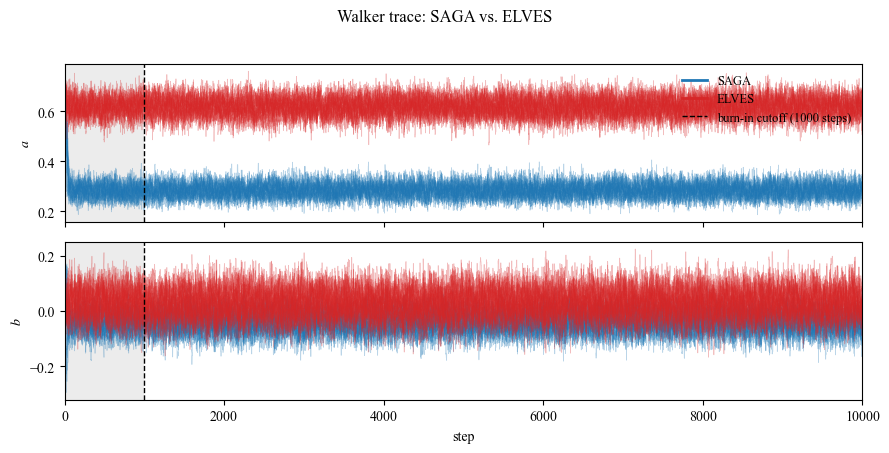

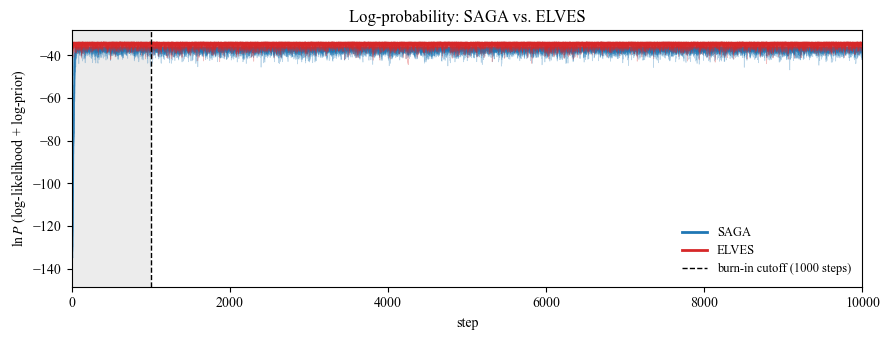

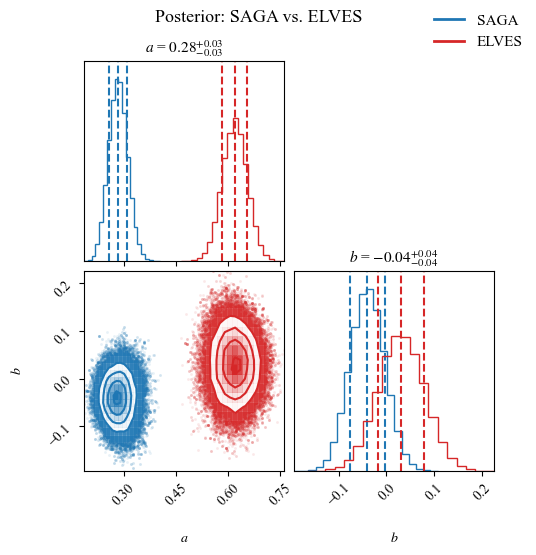

In [62]:
# re-fit SAGA and ELVES data with updated boostrapping
# (variable names below are local temporaries reused for both the SAGA and ELVES
# fits; despite an earlier 'tng100' name in a previous draft, this fit uses no TNG data)

# Consistency check: angle_array.txt (shared with the TNG100 fit computed in
# the companion notebook) should match the bin_centers bootstrap_90_observational
# _binned just computed above. If these ever diverge, the x-axis used below
# wouldn't actually match the fq_mean/fq_std values it's being fit against.
assert np.allclose(bin_centers, angle_array), (
    "angle_array.txt does not match the bin centers bootstrap_90_observational_binned "
    "just computed -- check both use the same bins/angle_range before trusting this fit."
)

# Binomial fit needs per-bin counts (n_i, k_i), not the bootstrap-mean and
# std. fq_mean/fq_std remain in use for the error bars on the plot below.
_edges_main = np.linspace(0, 90, 19)
n_saga_bin,  _ = np.histogram(saga_90, bins=_edges_main)
k_saga_bin,  _ = np.histogram(saga_90[saga_quenched.astype(bool)], bins=_edges_main)
n_elves_bin, _ = np.histogram(elves_90_correct, bins=_edges_main)
k_elves_bin, _ = np.histogram(np.asarray(elves_90_correct)[elves_quenched.astype(bool)],
                              bins=_edges_main)

# Drop bins with no galaxies (n_i == 0). The per-case fits later in the
# notebook use the same guard.
valid_saga  = n_saga_bin  > 0
valid_elves = n_elves_bin > 0
if not valid_saga.all():
    print(f"SAGA: dropping {(~valid_saga).sum()} bin(s) with no satellites.")
if not valid_elves.all():
    print(f"ELVES: dropping {(~valid_elves).sum()} bin(s) with no satellites.")

# SAGA -----------------------------------------------------------------
fit_saga = run_mcmc_fit(angle_array[valid_saga],
                         n_saga_bin[valid_saga], k_saga_bin[valid_saga],
                         initial_guess=[0.7, 0.025], n_steps=10_000, burnin=1000)

a_saga, b_saga = fit_saga["mean_params"]
a_saga_std, b_saga_std = fit_saga["std_params"]
print(f"SAGA:  a = {a_saga:.3f} +/- {a_saga_std:.3f}, "
      f"b = {b_saga:.3f} +/- {b_saga_std:.3f}   [binomial]")

# ELVES ------------------------------------------------------------------
fit_elves = run_mcmc_fit(angle_array[valid_elves],
                          n_elves_bin[valid_elves], k_elves_bin[valid_elves],
                          initial_guess=[0.7, 0.025], n_steps=10_000, burnin=1000)

a_elves, b_elves = fit_elves["mean_params"]
a_elves_std, b_elves_std = fit_elves["std_params"]
print(f"ELVES: a = {a_elves:.3f} +/- {a_elves_std:.3f}, "
      f"b = {b_elves:.3f} +/- {b_elves_std:.3f}   [binomial]")

# --- Diagnostics: walker trace (with burn-in), log-probability (with
#     burn-in), and corner plot, SAGA and ELVES overlaid -------------------
samplers_full = {"SAGA": fit_saga["sampler"], "ELVES": fit_elves["sampler"]}

plot_trace_with_burnin(samplers_full, burnin=1000, title="Walker trace: SAGA vs. ELVES")
plt.show()

plot_log_prob_with_burnin(samplers_full, burnin=1000, title="Log-probability: SAGA vs. ELVES")
plt.show()

plot_corner({"SAGA": fit_saga["samples"], "ELVES": fit_elves["samples"]},
            title="Posterior: SAGA vs. ELVES")
plt.show()

INCLUDE_TNG is False -- skipping TNG100 sinusoidal-fit panel.


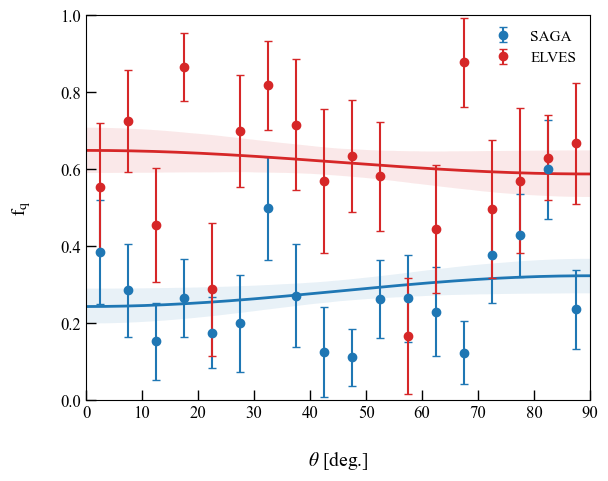

In [63]:
# Final SAGA + ELVES (+ optional TNG100) comparison figure: binned quenched
# fraction with the MCMC-fit sinusoid overlaid.
#
# FIX: this cell used to recompute its own a_saga/a_elves as
# np.mean(saga_quenched)/elves_mean, paired with hardcoded b/error "guesses"
# (0.03 +/- 0.07 for SAGA, 0.09 +/- 0.04 for ELVES) -- silently overwriting
# the real MCMC-fit a_saga/a_elves computed in the cell above for every cell
# that ran afterward, including the BIC/AIC comparison further down. Now
# uses the actual fit results (a_saga, b_saga, a_saga_std, b_saga_std, etc.)
# throughout, with no hardcoded numbers.
#
# Colors (saga_line/elves_line/etc.) are defined once, in the "Normalized
# Count per Azimuthal Angle Bin" cell above -- not redefined here.

if INCLUDE_TNG:
    fig, (ax_hist, ax_hist2) = plt.subplots(1, 2, figsize=(13, 5))
else:
    fig, ax_hist2 = plt.subplots(1, 1, figsize=(6.5, 5))

x = np.linspace(0, np.pi / 2, 1000)
theta_deg = (x * u.rad).to('degree').value
n_mc = 10000

if INCLUDE_TNG:
    ax_hist.errorbar(angle_array, fq_mean_1e8, yerr=fq_std_1e8, fmt='o', color='black', mfc='black', mec='black', mew=1, capsize=3)
    ax_hist.errorbar(angle_array, fq_mean_1e7, yerr=fq_std_1e7, fmt='o', color='black', mfc='black', mec='black', mew=1, capsize=3)
    ax_hist.errorbar(angle_array, fq_mean_1e6, yerr=fq_std_1e6, fmt='o', color='black', mfc='black', mec='black', mew=1, capsize=3)

    ax_hist.plot((x * u.rad).to('degree'), a_1e6 + b_1e6 * np.cos(2 * x), color='black', lw=2, ls=':')
    ax_hist.plot((x * u.rad).to('degree'), a_1e7 + b_1e7 * np.cos(2 * x), color='black', lw=2, ls='--')
    ax_hist.plot((x * u.rad).to('degree'), a_1e8 + b_1e8 * np.cos(2 * x), color='black', lw=2, ls='-')

    for a_fit, a_std, b_fit, b_std in [(a_1e6, a_1e6_std, b_1e6, b_1e6_std),
                                        (a_1e7, a_1e7_std, b_1e7, b_1e7_std),
                                        (a_1e8, a_1e8_std, b_1e8, b_1e8_std)]:
        a_samp = np.random.normal(a_fit, a_std, n_mc)
        b_samp = np.random.normal(b_fit, b_std, n_mc)
        y_mc = a_samp[:, None] + b_samp[:, None] * np.cos(2 * x)[None, :]
        y_low, y_high = np.percentile(y_mc, [16, 84], axis=0)
        ax_hist.fill_between(theta_deg, y_low, y_high, color='k', alpha=0.1, edgecolor=None)
else:
    print('INCLUDE_TNG is False -- skipping TNG100 sinusoidal-fit panel.')

# --- SAGA + ELVES: binned quenched fraction with the actual MCMC-fit
#     sinusoid (and its 16-84th percentile band) overlaid. ---
for label, color, fq_mean, fq_std, a_fit, a_std, b_fit, b_std in [
    ("SAGA",  saga_line,  fq_mean_saga,  fq_std_saga,  a_saga,  a_saga_std,  b_saga,  b_saga_std),
    ("ELVES", elves_line, fq_mean_elves, fq_std_elves, a_elves, a_elves_std, b_elves, b_elves_std),
]:
    ax_hist2.errorbar(angle_array, fq_mean, yerr=fq_std, fmt='o', color=color, mfc=color, mec=color, mew=1, capsize=3, label=label)
    ax_hist2.plot((x * u.rad).to('degree'), a_fit + b_fit * np.cos(2 * x), color=color, lw=2)

    a_samp = np.random.normal(a_fit, a_std, n_mc)
    b_samp = np.random.normal(b_fit, b_std, n_mc)
    y_mc = a_samp[:, None] + b_samp[:, None] * np.cos(2 * x)[None, :]
    y_low, y_high = np.percentile(y_mc, [16, 84], axis=0)
    ax_hist2.fill_between(theta_deg, y_low, y_high, color=color, alpha=0.1, edgecolor=None)

if INCLUDE_TNG:
    ax_hist.set_ylabel(r'$\mathrm{f_q}$', fontsize=14, labelpad=20)
    ax_hist.set_xlabel(r'$\theta$ [deg.]', fontsize=14, labelpad=20)
    ax_hist.set_xlim(0, 90)
    ax_hist.set_ylim(0, 1)
    ax_hist.tick_params(axis="both", which="major", direction="in", labelsize=12, length=7, width=1)
    ax_hist.tick_params(axis="both", which="minor", direction="in", labelsize=12, length=2, width=1)
    ax_hist2.set_yticks([])
else:
    ax_hist2.set_ylabel(r'$\mathrm{f_q}$', fontsize=14, labelpad=20)

ax_hist2.set_xlabel(r'$\theta$ [deg.]', fontsize=14, labelpad=20)
ax_hist2.set_xlim(0, 90)
ax_hist2.set_ylim(0, 1)
ax_hist2.legend(fontsize=11, loc='upper right', frameon=False)

ax_hist2.tick_params(axis="both", which="major", direction="in", labelsize=12, length=7, width=1)
ax_hist2.tick_params(axis="both", which="minor", direction="in", labelsize=12, length=2, width=1)

plt.subplots_adjust(wspace=0.05)
plt.show()

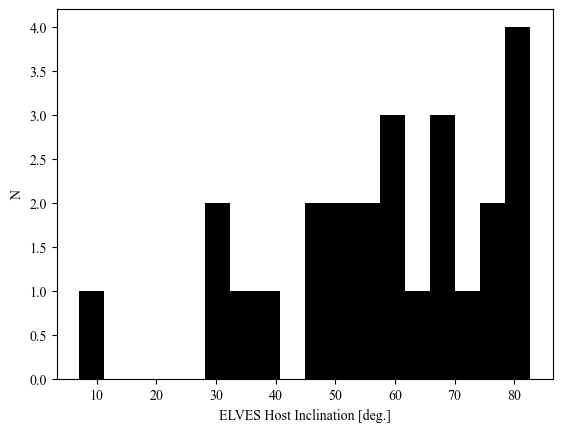

In [64]:
# Merge the refined ELVES host inclinations back into the full (unfiltered) host table
# so we can look up each host's inclination later (e.g. for inclination-based cuts).
# plot ELVES host inclination

elves_inclination_reformat = np.concatenate([c.filled(np.nan) for c in elves_inclination])
elves_PA_reformat = np.concatenate([c.astype(float).filled(np.nan) for c in elves_PA_host])


elves_inclination_reform = np.asarray(elves_inclination_reformat, dtype=float).ravel()
if len(elves_inclination_reform) != len(pa_indices):
    raise ValueError(
        f"Inclination length mismatch: len(elves_inclination_reform)={len(elves_inclination_reform)} "
        f"vs len(pa_indices)={len(pa_indices)}"
    )

hosts = hosts.reset_index(drop=True)
hosts.loc[pa_indices, "Inclination"] = elves_inclination_reform

# Propagate to the full host table for later host->inclination mapping
incl_by_host = pd.Series(hosts["Inclination"].values, index=hosts["Host"]).groupby(level=0).first()
hosts_unfiltered["Inclination"] = hosts_unfiltered["Host"].map(incl_by_host)

plt.hist(elves_inclination_reformat, color="k", bins=18)
plt.xlabel("ELVES Host Inclination [deg.]")
plt.ylabel("N")
plt.show()

In [65]:
# Mask-builder + plotting helpers for the combined SAGA+ELVES comparison below.
# (numpy/matplotlib re-imported here since this cell was originally standalone;
# no TNG data involved -- SAGA/ELVES only.)
#
# EFFICIENCY PASS -- behavior/selection logic is unchanged, only how it's computed:
#   1. _ensure_elves_cache() used to redo its pandas set_index/reindex from
#      scratch on every call (it's called 2-3x per case, since elves_mask()
#      also calls it). Now it's a true memo: computed once, reused after.
#   2. SAGA/ELVES "base" filters (r200+inclination, inclination-only) used to
#      get rebuilt once per sample/subgroup. Now built once per case and
#      reused (_saga_base_mask / _elves_base_mask).
#   3. The repeated "if elves_early == 'all': ... else: ..." block (it showed
#      up three times: top histogram, quenched-fraction panel, MCMC fits) is
#      now built once as a `groups` list; everything else just iterates over it.

# Built once, reused by every case/population instead of being rebuilt per call.
_THETA_FINE = np.linspace(0, np.pi / 2, 1000)
_THETA_DEG_FINE = np.degrees(_THETA_FINE)
_SAGA_SAMPLE_CODES = {"gold": 1, "silver": 2, "participation": 3}


def _ensure_saga_cache():
    pa = saga_PA_raw if "saga_PA_raw" in globals() else saga_PA
    if len(pa) != len(saga_joined):
        raise ValueError("saga_PA_raw must match saga_joined length. Rebuild saga_PA_raw from raw data.")

    if "theta90" not in saga_joined.colnames:
        saga_joined["theta90"] = map_to_0_90(np.asarray(pa))

    if "host_incl_deg" not in saga_joined.colnames:
        saga_joined["host_incl_deg"] = np.degrees(np.arccos(np.asarray(saga_joined["HOST_ba"], dtype=float)))

    if "radius_limit" not in saga_joined.colnames:
        # radius_limit (module-level) was computed in saga_sats's row order,
        # but join() reorders rows by HOSTID -- so it doesn't line up with
        # saga_joined. r200c_hosts is one value per host, so just look each
        # row up by HOSTID instead of relying on row position.
        host_r200c = dict(zip(saga_sats['HOSTID'], r200c_hosts))
        r200c_per_row = np.array([host_r200c[h] for h in saga_joined["HOSTID"]])
        saga_joined["radius_limit"] = np.asarray(saga_joined["Rhost"], dtype=float) < r200c_per_row


def _ensure_elves_cache():
    """Populate elves_90 / elves_host_incl_deg / elves_host_is_early exactly
    once. Previously only elves_90 was memoized -- the two pandas reindex
    calls below ran on every single invocation (multiple times per case)."""
    global elves_90, elves_host_incl_deg, elves_host_is_early

    if "elves_90" not in globals():
        elves_90 = np.asarray(map_to_0_90(np.asarray(elves_PA)), dtype=float).ravel()

    if "elves_host_incl_deg" in globals() and "elves_host_is_early" in globals():
        return  # already built this session -- nothing else to do

    host_names = sats["Host"].iloc[kept_indices]

    incl_map = hosts_unfiltered.set_index("Host")["Inclination"]
    elves_host_incl_deg = incl_map.reindex(host_names).to_numpy(dtype=float)

    early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)
    elves_host_is_early = early_map.reindex(host_names).fillna(False).to_numpy(dtype=bool)


# -----------------------
# Mask builders
# -----------------------
def _saga_base_mask(incl_min, r200):
    """r200 + inclination filter shared by every SAGA sample -- computed once
    per case instead of once per sample (see _combine_saga_mask)."""
    _ensure_saga_cache()
    m = np.asarray(saga_joined["radius_limit"], dtype=bool) if r200 else np.ones(len(saga_joined), dtype=bool)
    if incl_min and incl_min > 0:
        m = m & (np.asarray(saga_joined["host_incl_deg"]) >= float(incl_min))
    return m


def saga_mask(sample_sel="gold", incl_min=0, r200=True):
    m = _saga_base_mask(incl_min, r200)
    if sample_sel != "all":
        code = _SAGA_SAMPLE_CODES.get(sample_sel, sample_sel)
        m = m & (np.asarray(saga_joined["sample"]) == code)
    return m


def _combine_saga_mask(samples, incl_min, r200):
    m = _saga_base_mask(incl_min, r200)
    if "all" in samples:
        return m
    wanted = [_SAGA_SAMPLE_CODES.get(s, s) for s in samples]
    return m & np.isin(np.asarray(saga_joined["sample"]), wanted)


def _elves_base_mask(incl_min):
    """Inclination filter shared by early/late/all -- computed once per case
    instead of once per elves_mask() call."""
    _ensure_elves_cache()
    if incl_min and incl_min > 0:
        return np.isfinite(elves_host_incl_deg) & (elves_host_incl_deg >= float(incl_min))
    # incl_min == 0 -> no inclination cut; keep hosts with unknown inclination too.
    return np.ones(len(elves_host_incl_deg), dtype=bool)


def elves_mask(incl_min=0, early_type="all"):
    """
    early_type: 'all' | True | False
    True  -> keep only early-type hosts
    False -> keep only non-early-type hosts
    """
    m = _elves_base_mask(incl_min)
    if early_type == "all":
        return m
    if early_type is True:
        return m & elves_host_is_early
    if early_type is False:
        return m & ~elves_host_is_early
    raise ValueError("early_type must be 'all', True, or False")


def run_case_combined(case_name, CASES):
    cfg = CASES[case_name]
    incl_min = cfg.get("incl_min", 0)
    saga_samples = cfg.get("saga_samples", ["gold", "silver", "participation"])
    saga_r200 = cfg.get("saga_r200", True)
    elves_early = cfg.get("elves_early_type", "all")  # 'all'/'none' (combined), 'split' (early+late separately), or True/False
    bins = cfg.get("bins", 18)
    density = cfg.get("density", True)
    Nboot = cfg.get("bootstrap_N", 10000)
    mcmc_steps = cfg.get("mcmc_steps", 5000)
    mcmc_burnin = cfg.get("mcmc_burnin", 500)

    # --- Build (label, color, theta, quenched) groups once. Everything below
    #     (histogram, quenched-fraction, MCMC fit) just iterates over this,
    #     instead of branching on elves_early three separate times. ---
    m_saga = _combine_saga_mask(saga_samples, incl_min=incl_min, r200=saga_r200)
    saga_theta = np.asarray(saga_joined["theta90"])[m_saga]
    saga_q     = np.asarray(saga_joined["quenched"], dtype=int)[m_saga]

    elves_theta = np.asarray(elves_90, dtype=float).ravel()
    elves_q     = np.asarray(elves_quenched, dtype=int).ravel()

    groups = [("SAGA", "black", saga_theta, saga_q)]
    if elves_early == "split":
        elves_base = _elves_base_mask(incl_min)
        mE, mL = elves_base & elves_host_is_early, elves_base & ~elves_host_is_early
        groups.append(("ELVES early", "firebrick", elves_theta[mE], elves_q[mE]))
        groups.append(("ELVES late",  "steelblue", elves_theta[mL], elves_q[mL]))
    else:
        # "all" (and "none", kept as a synonym) -> early+late combined into one
        # group. True/False -> early-only/late-only. "split" (above) is the
        # only option that breaks early/late into two separate fitted groups.
        m_all = elves_mask(incl_min=incl_min,
                            early_type="all" if elves_early in ("all", "none") else elves_early)
        groups.append(("ELVES", "firebrick", elves_theta[m_all], elves_q[m_all]))

    # --- figure with top (angles) and bottom (fq) ---
    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
    edges = np.linspace(0, 90, bins + 1)

    # ===== Top: Angular distribution =====
    for label, color, theta, _q in groups:
        ax_top.hist(theta, bins=edges, histtype="step", linewidth=2, density=density,
                    color=color, label=f"{label} (N={len(theta)})")

    ax_top.set_title(f"Angular distribution (i \u2265 {incl_min}\u00b0, SAGA r200={saga_r200})")
    ax_top.set_ylabel("PDF" if density else "N")
    ax_top.legend(frameon=False, fontsize=10)
    ax_top.set_xlim(0, 90)

    # ===== Bottom: Quenched fraction + MCMC sinusoidal fit, per group =====
    fits = {}
    for label, color, theta, q in groups:
        # Bootstrap fq/fe are still computed -- only for the plotted error
        # bars; the binomial fit uses per-bin (n_i, k_i) instead.
        bc, fq, fe = bootstrap_90_observational_binned(theta, q, N=Nboot, bins=bins, angle_range=(0, 90))
        ax_bot.errorbar(bc, fq, yerr=fe, fmt="o", ms=4, capsize=3, color=color, label=label)

        edges_case = np.linspace(0, 90, bins + 1)
        theta_arr = np.asarray(theta)
        q_arr = np.asarray(q, dtype=float)
        n_i_case, _ = np.histogram(theta_arr, bins=edges_case)
        k_i_case, _ = np.histogram(theta_arr[q_arr > 0.5], bins=edges_case)

        valid = n_i_case > 0
        if valid.sum() < 3:
            print(f"  [skip MCMC] case '{case_name}' / '{label}': "
                  f"fewer than 3 usable bins ({valid.sum()}).")
            continue

        a0 = float(np.clip(np.nanmean(fq[valid]) if np.any(np.isfinite(fq[valid])) else 0.5,
                           0.05, 0.95))
        fit = run_mcmc_fit(bc[valid], n_i_case[valid], k_i_case[valid],
                            initial_guess=[a0, 0.02],
                            n_steps=mcmc_steps, burnin=mcmc_burnin, progress=False)
        fits[label] = fit

        a_fit, b_fit = fit["mean_params"]
        ax_bot.plot(_THETA_DEG_FINE, a_fit + b_fit * np.cos(2 * _THETA_FINE),
                    color=color, lw=2, ls="--")

    ax_bot.set_xlabel(r"Projected Offset Angle $\theta$ [deg] (folded 0-90)")
    ax_bot.set_ylabel(r"$f_q$")
    ax_bot.set_ylim(0, 1)
    ax_bot.legend(frameon=False, fontsize=10)

    fig.tight_layout()
    plt.show()

    # --- MCMC diagnostics for this case: trace, log-probability, corner ---
    if fits:
        samplers = {label: fit["sampler"] for label, fit in fits.items()}
        samples  = {label: fit["samples"] for label, fit in fits.items()}

        plot_trace_with_burnin(samplers, burnin=mcmc_burnin,
                                title=f"{case_name}: walker trace")
        plt.show()

        plot_log_prob_with_burnin(samplers, burnin=mcmc_burnin,
                                   title=f"{case_name}: log-probability")
        plt.show()

        plot_corner(samples, title=f"{case_name}: posterior")
        plt.show()

        for label, fit in fits.items():
            a_f, b_f = fit["mean_params"]
            a_fs, b_fs = fit["std_params"]
            print(f"  [{case_name}] {label}: a = {a_f:.3f} +/- {a_fs:.3f}, "
                  f"b = {b_f:.3f} +/- {b_fs:.3f}   [binomial]")
    else:
        print(f"  [{case_name}] no population had enough bins for an MCMC fit.")

    return fig, fits




=== Case 'baseline' ===


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_81542/2701333590.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_map = hosts_unfiltered.set_index("Host")["Early_type_host?"].fillna(False).astype(bool)


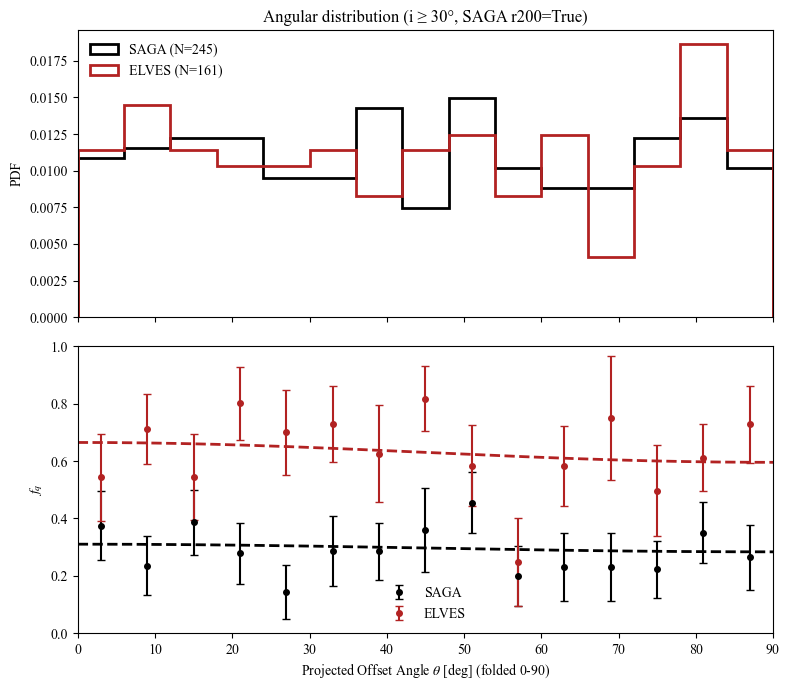

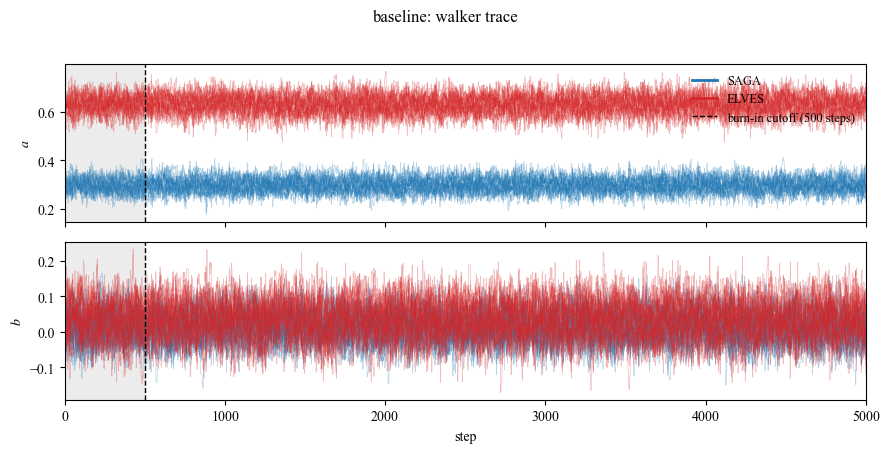

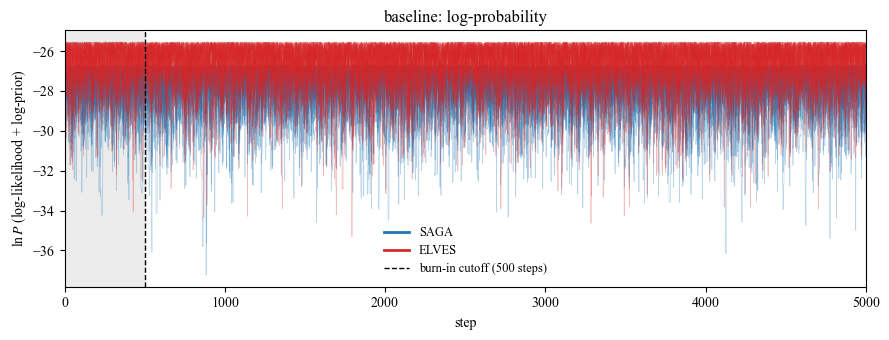

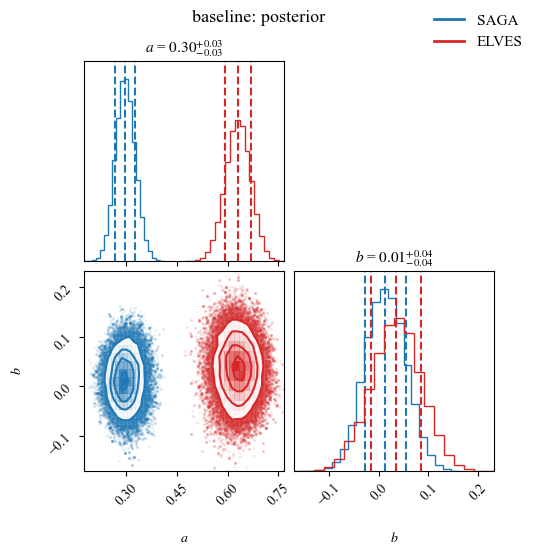

  [baseline] SAGA: a = 0.297 +/- 0.029, b = 0.013 +/- 0.041   [binomial]
  [baseline] ELVES: a = 0.630 +/- 0.038, b = 0.035 +/- 0.050   [binomial]
Case 'baseline' completed.


In [66]:
# Define several selection-cut cases and run the combined SAGA+ELVES comparison
# (angle distribution + quenched fraction + MCMC sinusoidal fit) for each one.
# Each case now also produces a walker-trace plot, a log-probability plot
# (both with the burn-in region shaded), and a corner plot of the (a, b)
# posterior -- one population overlaid per line in the case (e.g. SAGA vs.
# ELVES, or ELVES early vs. late).
CASES = {
    "baseline": {
        "incl_min": 30,
        "saga_samples": ["gold", "silver"],
        "saga_r200": True,
        "elves_early_type": 'all',   # 'all'/'none' (combined), 'split' (early+late separately), or True/False
        "bins": 15,
        "bootstrap_N": 10000,
    }
}

case_fits = {}  # case_name -> {population_label: fit_result_dict}
for case_name in CASES:
    print(f"\n=== Case '{case_name}' ===")
    fig, fits = run_case_combined(case_name, CASES)
    case_fits[case_name] = fits
    print(f"Case '{case_name}' completed.")




## BIC/AIC Analysis:

In [67]:
# Debug diagnostics: sanity-check the ELVES inclination/early-type caching and
# selection-cut counts used by the mask builders above (SAGA/ELVES only, no TNG).
import numpy as np
import pandas as pd

# ---- rebuild ELVES cache (with safe early-type conversion) ----
def _ensure_elves_cache_debug():
    global elves_90, elves_host_incl_deg, elves_host_is_early

    elves_90 = np.asarray(map_to_0_90(np.asarray(elves_PA)), dtype=float).ravel()

    host_incl_map = hosts_unfiltered.set_index("Host")["Inclination"]
    elves_host_incl_deg = host_incl_map.reindex(sats["Host"].iloc[kept_indices]).to_numpy(dtype=float)

    early_series = hosts_unfiltered.set_index("Host")["Early_type_host?"]
    early_series = early_series.infer_objects(copy=False).fillna(False)
    early_map = early_series.astype(bool)

    elves_host_is_early = early_map.reindex(sats["Host"].iloc[kept_indices]).fillna(False).to_numpy(dtype=bool)

_ensure_elves_cache_debug()

# ---- basic length sanity ----
print("len(elves_90):", len(elves_90))
print("len(elves_quenched):", len(elves_quenched))
print("len(elves_host_incl_deg):", len(elves_host_incl_deg))
print("len(elves_host_is_early):", len(elves_host_is_early))

# ---- NaN / missing checks ----
print("NaN inclinations:", np.isnan(elves_host_incl_deg).sum())
print("Early-type True count:", np.sum(elves_host_is_early))
print("Early-type False count:", np.sum(~elves_host_is_early))

# ---- inclination filter counts ----
for cut in [0, 30, 45]:
    m_incl = np.isfinite(elves_host_incl_deg) & (elves_host_incl_deg >= cut)
    print(f"i >= {cut}°: {m_incl.sum()}")

# ---- combined filters ----
for cut in [0, 30, 45]:
    m_incl = np.isfinite(elves_host_incl_deg) & (elves_host_incl_deg >= cut)
    mE = m_incl & elves_host_is_early
    mL = m_incl & (~elves_host_is_early)
    print(f"i >= {cut}°: early={mE.sum()}, late={mL.sum()}")

# ---- show a few mappings to verify host name alignment ----
print("\nExample host mapping (first 10):")
for h, inc, et in list(zip(sats["Host"].iloc[kept_indices][:10],
                           elves_host_incl_deg[:10],
                           elves_host_is_early[:10])):
    print(h, inc, et)

len(elves_90): 177
len(elves_quenched): 177
len(elves_host_incl_deg): 177
len(elves_host_is_early): 177
NaN inclinations: 0
Early-type True count: 28
Early-type False count: 149
i >= 0°: 177
i >= 30°: 161
i >= 45°: 137
i >= 0°: early=28, late=149
i >= 30°: early=28, late=133
i >= 45°: early=28, late=109

Example host mapping (first 10):
NGC253 78.2155532836914 False
NGC253 78.2155532836914 False
NGC253 78.2155532836914 False
NGC253 78.2155532836914 False
NGC253 78.2155532836914 False
NGC628 7.068383693695068 False
NGC628 7.068383693695068 False
NGC628 7.068383693695068 False
NGC628 7.068383693695068 False
NGC628 7.068383693695068 False


/var/folders/52/r93wsrcx1b3cnhc1tg56pl240000gn/T/ipykernel_81542/3039735693.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  early_series = early_series.infer_objects(copy=False).fillna(False)


In [68]:
# calculate how many std the mean amplitude b is from 0, for the TNG100 (1e6) fit
if INCLUDE_TNG:
    b_samp = np.random.normal(b_1e6, b_1e6_std, n_mc)

    #plt.hist(b_samp,bins=100,histtype='step',color='k');

    b_mean = np.mean(b_samp)
    b_std  = np.std(b_samp)
    sigma_significance = np.abs(b_mean / b_std)
    print(sigma_significance)
else:
    print('INCLUDE_TNG is False -- skipping TNG100 (1e6) amplitude-significance check.')

INCLUDE_TNG is False -- skipping TNG100 (1e6) amplitude-significance check.


In [69]:
if INCLUDE_TNG:
    np.abs(b_1e6/b_1e6_std)
else:
    print('INCLUDE_TNG is False -- skipping TNG100 (1e6) check.')

INCLUDE_TNG is False -- skipping TNG100 (1e6) check.


### Interpretation: If the amplitude b = 0, then the sinsoidal function is merely a constant, or the quench fraction. We can therefore ask, how many std away from 0 is the parameter b mean? We find that there is significant overlap in the SAGA and ELVES b parameter. However, there is less overlap in the TNG100-1 subsamples.

In [70]:
# calculate how many std the mean amplitude b is from 0, for SAGA, ELVES,
# and (optionally) each TNG100 mass threshold
# calulate how many std the mean is from 0 (for the parameter b, such that b = 0 is consistent with a st)

n_mc = 100000
b_samp = np.random.normal(b_saga, b_saga_std, n_mc)

#plt.hist(b_samp,bins=100,histtype='step',color='k');

b_mean = np.mean(b_samp)
b_std  = np.std(b_samp)
sigma_significance = np.abs(b_mean / b_std)
print(sigma_significance)

#######

b_samp = np.random.normal(b_elves, b_elves_std, n_mc)

#plt.hist(b_samp,bins=100,histtype='step',color='k');

b_mean = np.mean(b_samp)
b_std  = np.std(b_samp)
sigma_significance = np.abs(b_mean / b_std)
print(sigma_significance)

if INCLUDE_TNG:
    b_samp = np.random.normal(b_1e8, b_1e8_std, n_mc)

    #plt.hist(b_samp,bins=100,histtype='step',color='k');

    b_mean = np.mean(b_samp)
    b_std  = np.std(b_samp)
    sigma_significance = np.abs(b_mean / b_std)
    print(sigma_significance)

    #######

    b_samp = np.random.normal(b_1e7, b_1e7_std, n_mc)

    #plt.hist(b_samp,bins=100,histtype='step',color='k');

    b_mean = np.mean(b_samp)
    b_std  = np.std(b_samp)
    sigma_significance = np.abs(b_mean / b_std)
    print(sigma_significance)

    #######

    b_samp = np.random.normal(b_1e6, b_1e6_std, n_mc)

    #plt.hist(b_samp,bins=100,histtype='step',color='k');

    b_mean = np.mean(b_samp)
    b_std  = np.std(b_samp)
    sigma_significance = np.abs(b_mean / b_std)
    print(sigma_significance)
else:
    print('INCLUDE_TNG is False -- skipping TNG100 (1e8/1e7/1e6) significance checks.')

1.0933224175835583
0.6283006517756062
INCLUDE_TNG is False -- skipping TNG100 (1e8/1e7/1e6) significance checks.


In [71]:
# calculate the BIC (and AIC) for the sinusoidal fit versus constant
# be careful of f value -- is this an extra parmameter?

def sinusoid(x, a, b, f):
    
    return a + b * np.cos(2 * x)

def BIC(x_data, y_data, y_err, a_fit, b_fit, f_fit):

    resid = y_data - sinusoid(x_data, a_fit, b_fit, f_fit)
    print(resid)                       
    n = len(y_data)
    k = 2
    logL = -0.5 * np.sum((resid / y_err)**2 + np.log(2*np.pi*y_err**2))
    bic_sin = k * np.log(n) - 2 * logL
    print("BIC Sinudoid Fit =", bic_sin) 
    aic_sin = 2*k - 2*logL
    print("AIC Sinudoid Fit =", aic_sin) 

    resid_const = y_data - np.mean(y_data)
    k_const = 1
    logL_const = -0.5 * np.sum((resid_const / y_err)**2 + np.log(2*np.pi*y_err**2))
    bic_const = k_const * np.log(n) - 2 * logL_const
    print("BIC Constant Fit =", bic_const)
    aic_const = 2*k - 2*logL_const
    print("AIC Constant Fit =", aic_const) 

    print('Delta BIC =',np.abs(bic_const-bic_sin))
    print('Delta AIC =',np.abs(aic_const-aic_sin))
    if bic_const < bic_sin:
        print("From BIC, Constant model preferred")
    else:
        print("From BIC, Sinusoid model preferred")

    if aic_const < aic_sin:
        print("From AIC, Constant model preferred")
    else:
        print("From AIC, Sinusoid model preferred")

def BIC_binomial(bin_centers_deg, n_i, k_i, a_fit, b_fit):
    """Binomial-likelihood BIC/AIC for the sinusoid vs. constant comparison.
    Matches the binomial likelihood used for the SAGA/ELVES fits above."""
    mask = n_i > 0
    bc = np.asarray(bin_centers_deg)[mask]
    n = np.asarray(n_i)[mask]
    k = np.asarray(k_i)[mask]

    # sinusoid model
    p_sin = np.clip(a_fit + b_fit * np.cos(2 * np.radians(bc)), 1e-6, 1 - 1e-6)
    logL_sin = float(np.sum(scipy.stats.binom.logpmf(k, n, p_sin)))
    n_data, k_sin = len(k), 2
    bic_sin = k_sin * np.log(n_data) - 2 * logL_sin
    aic_sin = 2 * k_sin - 2 * logL_sin
    print("BIC Sinusoid Fit =", bic_sin)
    print("AIC Sinusoid Fit =", aic_sin)

    # constant model: MLE p = sum(k) / sum(n)
    p_const = np.clip(np.sum(k) / np.sum(n), 1e-6, 1 - 1e-6)
    logL_const = float(np.sum(scipy.stats.binom.logpmf(k, n, np.full_like(p_sin, p_const))))
    k_const = 1
    bic_const = k_const * np.log(n_data) - 2 * logL_const
    aic_const = 2 * k_const - 2 * logL_const
    print("BIC Constant Fit =", bic_const)
    print("AIC Constant Fit =", aic_const)

    print('Delta BIC =', np.abs(bic_const - bic_sin))
    print('Delta AIC =', np.abs(aic_const - aic_sin))
    if bic_const < bic_sin:
        print("From BIC, Constant model preferred")
    else:
        print("From BIC, Sinusoid model preferred")
    if aic_const < aic_sin:
        print("From AIC, Constant model preferred")
    else:
        print("From AIC, Sinusoid model preferred")

print('ELVES:')
BIC_binomial(angle_array, n_elves_bin, k_elves_bin, a_elves, b_elves)
print(' ')
print('SAGA:')
BIC_binomial(angle_array, n_saga_bin, k_saga_bin, a_saga, b_saga)
print(' ')

if INCLUDE_TNG:
    print('TNG100-1, > 1e8:')
    BIC(angle_array, fq_mean_1e8, fq_std_1e8, a_1e8, b_1e8, f_1e8)
    print(' ')
    print('TNG100-1, > 1e7:')
    BIC(angle_array, fq_mean_1e7, fq_std_1e7, a_1e7, b_1e7, f_1e7)
    print(' ')
    print('TNG100-1, > 1e6:')
    BIC(angle_array, fq_mean_1e6, fq_std_1e6, a_1e6, b_1e6, f_1e6)
else:
    print('INCLUDE_TNG is False -- skipping TNG100-1 BIC/AIC comparison.')

ELVES:
BIC Sinusoid Fit = 73.376825404903
AIC Sinusoid Fit = 71.59608188911068
BIC Constant Fit = 70.88433384824926
AIC Constant Fit = 69.9939620903531
Delta BIC = 2.4924915566537464
Delta AIC = 1.6021197987575846
From BIC, Constant model preferred
From AIC, Constant model preferred
 
SAGA:
BIC Sinusoid Fit = 78.0591137291779
AIC Sinusoid Fit = 76.27837021338557
BIC Constant Fit = 76.43903537118932
AIC Constant Fit = 75.54866361329316
Delta BIC = 1.6200783579885751
Delta AIC = 0.7297066000924133
From BIC, Constant model preferred
From AIC, Constant model preferred
 
INCLUDE_TNG is False -- skipping TNG100-1 BIC/AIC comparison.


### Interpretation: Instead of looking at the amplitude b, we can instead ask: How much better of a fit is the sinusoidal function compared to a constant (the mean quench fraction across all angle bins). This can be calculated using both the BIC (penalizes number of paramaeters more) and AIC. We find that all data are better fit with a constant. Supposedly the AIC for the SAGA data is slightly lower for the sinusoid compared to the constant model, but the $\Delta$BIC is 1.15. As a good rule of thumb, > 10 suggests that there is strong evidence.

## Alignment Test

In [72]:
# Effect-size test: is there a net alignment signal (non-zero <cos(2*theta)>)?
# Refactored from duplicated SAGA/ELVES cells into one function, called once per population.

def bootstrap_cos2theta_ci(theta_deg, label, B=5000, seed=0):
    theta_rad = np.deg2rad(np.asarray(theta_deg))

    A_obs = np.mean(np.cos(2 * theta_rad))

    rng = np.random.default_rng(seed)
    n = len(theta_rad)
    A_boot = []
    for _ in range(B):
        sample = rng.choice(theta_rad, size=n, replace=True)
        A_boot.append(np.mean(np.cos(2 * sample)))

    lo, hi = np.percentile(A_boot, [2.5, 97.5])
    print(label)
    print(f"<cos(2θ)> = {A_obs:.4f}")
    print(f"95% CI: [{lo:.4f}, {hi:.4f}]")


bootstrap_cos2theta_ci(saga_90, "SAGA")
bootstrap_cos2theta_ci(elves_90, "ELVES")

SAGA
<cos(2θ)> = -0.0558
95% CI: [-0.1410, 0.0330]


ELVES
<cos(2θ)> = 0.0119
95% CI: [-0.0946, 0.1170]


In [73]:
# Two-sample KS test + cluster(host)-bootstrap CI + cluster-aware permutation test:
# do quenched vs. star-forming satellites differ in angle distribution / alignment?
# Refactored from duplicated SAGA/ELVES cells (each with its own copy of
# permute_labels_within_host) into one function, called once per population.
from scipy.stats import ks_2samp, kstest


def permute_labels_within_host(q, h, rng):
    """Permute labels WITHIN each host; preserves per-host clustering and class sizes."""
    q_perm = q.copy()
    for hh in np.unique(h):
        idx = np.where(h == hh)[0]
        q_perm[idx] = rng.permutation(q_perm[idx])
    return q_perm


def alignment_ks_permutation_test(theta_deg, quenched, host_id, label, B=5000, Bperm=5000, seed=0):
    # Inputs:
    # theta_deg: folded angles in [0, 90], shape (N,)
    # quenched:  1 for quenched, 0 for star-forming, shape (N,)
    # host_id:   host identifier per satellite, shape (N,)
    theta_deg = np.asarray(theta_deg)
    quenched = np.asarray(quenched).astype(int)
    host_id = np.asarray(host_id)

    print(f"{label}: Testing Whether Quench and Star forming follow different distribution")

    th_q  = theta_deg[quenched == 1]
    th_sf = theta_deg[quenched == 0]

    print(f"{label}:", kstest(theta_deg, 'uniform', args=(0, 90)))

    # --- (1) Two-sample KS ---
    D, p_ks = ks_2samp(th_q, th_sf, alternative='two-sided')
    # Extract scalar values to avoid formatting errors
    D = D.item() if hasattr(D, 'item') else (float(D[0]) if hasattr(D, '__len__') else D)
    p_ks = p_ks.item() if hasattr(p_ks, 'item') else (float(p_ks[0]) if hasattr(p_ks, '__len__') else p_ks)

    # --- (2) ΔA effect size ---
    c2 = np.cos(2 * np.deg2rad(theta_deg))
    A_q  = c2[quenched == 1].mean()
    A_sf = c2[quenched == 0].mean()
    dA   = A_q - A_sf

    print(f"KS: D={D:.4f}, p={p_ks:.3g}")
    print(f"A_q={A_q:.4f}, A_sf={A_sf:.4f}, ΔA={dA:.4f}")

    # --- (3) 95% CI for ΔA via cluster (host) bootstrap ---
    rng = np.random.default_rng(seed)
    hosts = np.unique(host_id)
    dA_boot = []

    for _ in range(B):
        boot_hosts = rng.choice(hosts, size=len(hosts), replace=True)
        # keep all satellites belonging to sampled hosts
        mask = np.isin(host_id, boot_hosts)
        c2_b = c2[mask]
        q_b  = quenched[mask]
        if (q_b == 1).any() and (q_b == 0).any():
            dA_boot.append(c2_b[q_b==1].mean() - c2_b[q_b==0].mean())

    lo, hi = np.percentile(dA_boot, [2.5, 97.5])
    print(f"ΔA 95% CI: [{lo:.4f}, {hi:.4f}]")

    # --- (4) Cluster-aware permutation p-values ---
    # rng continues from the CI bootstrap above (not reseeded), matching the
    # original notebook's single shared rng per population.
    dA_perm = []
    D_perm  = []

    for _ in range(Bperm):
        q_p = permute_labels_within_host(quenched, host_id, rng)
        # ΔA under permuted labels
        A_q_p  = c2[q_p==1].mean() if (q_p==1).any() else np.nan
        A_sf_p = c2[q_p==0].mean() if (q_p==0).any() else np.nan
        dA_perm.append(A_q_p - A_sf_p)

        # KS under permuted labels
        th_q_p  = theta_deg[q_p == 1]
        th_sf_p = theta_deg[q_p == 0]
        if len(th_q_p) > 0 and len(th_sf_p) > 0:
            Dp, _ = ks_2samp(th_q_p, th_sf_p, alternative='two-sided')
            D_perm.append(Dp.item() if hasattr(Dp, 'item') else (float(Dp[0]) if hasattr(Dp, '__len__') else Dp))

    dA_perm = np.array(dA_perm, dtype=float)
    D_perm  = np.array(D_perm, dtype=float)

    p_perm_dA = (np.sum(np.abs(dA_perm) >= abs(dA)) + 1) / (np.sum(~np.isnan(dA_perm)) + 1)
    p_perm_KS = (np.sum(D_perm >= D) + 1) / (len(D_perm) + 1)

    print(f"Permutation p (ΔA): {p_perm_dA:.4g}")
    print(f"Permutation p (KS): {p_perm_KS:.4g}")